# Análises temporais do SINAN

Este notebook realiza análises temporais agregadas dos registros de dengue
do SINAN, considerando principalmente a semana epidemiológica de notificação.

Os principais objetivos são:

- analisar a distribuição semanal dos registros de dengue;
- caracterizar a evolução temporal dos registros no Brasil;
- analisar séries temporais segundo UF;
- identificar semanas com maior número de registros;
- calcular indicadores temporais agregados;
- comparar o comportamento temporal entre as UFs;
- caracterizar períodos recentes de aumento, redução ou estabilidade;
- produzir artefatos analíticos para consolidação e geração posterior
  de documentos semânticos.

As análises deste notebook representam a distribuição temporal dos
registros disponíveis no SINAN e não devem ser interpretadas isoladamente
como estimativas de incidência ou transmissão.

**Resumo** da estrutura proposta do notebook
1. Montagem do Google Drive
2. Imports
3. Configuração
4. Carregamento dos dados enriquecidos
5. Verificação das variáveis temporais
6. Distribuição semanal de registros — Brasil
7. Distribuição semanal por UF
8. Indicadores temporais por UF
9. Janela recente e variação temporal
10. Identificação de semanas de pico
11. Comparação entre UFs
12. Visualizações
13. Produtos finais
14. Inventário
15. Salvamento
16. Validação dos arquivos salvos

## 1 - Montagem do drive

In [1]:
from google.colab import drive
import os

drive.mount("/content/drive")

Mounted at /content/drive


##2 - Imports

In [2]:
import pandas as pd
import numpy as np

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 3. Configuração

In [3]:
# ============================================================
# 3 — CONFIGURAÇÃO
# ============================================================

ANO = 2026

BASE_DIR = Path(
    "/content/drive/MyDrive/Doutorado/arbovirus_rag"
)

ARQUIVO_ENTRADA = (
    BASE_DIR
    / "data_processed"
    / "SINAN"
    / str(ANO)
    / f"sinan_dengue_{ANO}_enriquecido.parquet"
)

PASTA_SAIDA = (
    BASE_DIR
    / "data_analytics"
    / "SINAN"
    / str(ANO)
    / "temporais"
)

PASTA_SAIDA.mkdir(
    parents=True,
    exist_ok=True
)

print(
    f"Arquivo de entrada:\n{ARQUIVO_ENTRADA}"
)

print()

print(
    f"Pasta de saída:\n{PASTA_SAIDA}"
)

Arquivo de entrada:
/content/drive/MyDrive/Doutorado/arbovirus_rag/data_processed/SINAN/2026/sinan_dengue_2026_enriquecido.parquet

Pasta de saída:
/content/drive/MyDrive/Doutorado/arbovirus_rag/data_analytics/SINAN/2026/temporais


## 4. Carregar o dataframe enriquecido

In [4]:
# ============================================================
# CARREGAMENTO
# ============================================================

df = pd.read_parquet(
    ARQUIVO_ENTRADA
)

print(
    f"Registros carregados: {len(df):,}"
)

print(
    f"Quantidade de variáveis: {df.shape[1]}"
)

display(
    df.head()
)

Registros carregados: 444,266
Quantidade de variáveis: 171


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,SEM_PRI,ANO_NASC,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_PAIS,DT_INVEST,ID_OCUPA_N,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,DT_CHIK_S1,DT_CHIK_S2,DT_PRNT,RES_CHIKS1,RES_CHIKS2,RESUL_PRNT,DT_SORO,RESUL_SORO,DT_NS1,RESUL_NS1,DT_VIRAL,RESUL_VI_N,DT_PCR,RESUL_PCR_,SOROTIPO,HISTOPA_N,IMUNOH_N,HOSPITALIZ,DT_INTERNA,UF,MUNICIPIO,TPAUTOCTO,COUFINF,COPAISINF,COMUNINF,CLASSI_FIN,CRITERIO,DOENCA_TRA,CLINC_CHIK,EVOLUCAO,DT_OBITO,DT_ENCERRA,ALRM_HIPOT,ALRM_PLAQ,ALRM_VOM,ALRM_SANG,ALRM_HEMAT,ALRM_ABDOM,ALRM_LETAR,ALRM_HEPAT,ALRM_LIQ,DT_ALRM,GRAV_PULSO,GRAV_CONV,GRAV_ENCH,GRAV_INSUF,GRAV_TAQUI,GRAV_EXTRE,GRAV_HIPOT,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,DT_GRAV,MANI_HEMOR,EPISTAXE,GENGIVO,METRO,PETEQUIAS,HEMATURA,SANGRAM,LACO_N,PLASMATICO,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET,FLXRECEBI,MIGRADO_W,SEMANA_EPIDEMIOLOGICA,ANO_SEM_NOT,UF_NAME,SOROTIPO_ANALITICO,HOSPITALIZ_ANALITICO,EVOLUCAO_ANALITICO,SOROTIPO_DECODED,HOSPITALIZ_DECODED,EVOLUCAO_DECODED,FEBRE_DECODED,MIALGIA_DECODED,CEFALEIA_DECODED,EXANTEMA_DECODED,VOMITO_DECODED,NAUSEA_DECODED,DOR_COSTAS_DECODED,CONJUNTVIT_DECODED,ARTRITE_DECODED,ARTRALGIA_DECODED,PETEQUIA_N_DECODED,LEUCOPENIA_DECODED,LACO_DECODED,DOR_RETRO_DECODED,DIABETES_DECODED,HEMATOLOG_DECODED,HEPATOPAT_DECODED,RENAL_DECODED,HIPERTENSA_DECODED,ACIDO_PEPT_DECODED,AUTO_IMUNE_DECODED,TPAUTOCTO_DECODED,COUFINF_NORMALIZADO,COMUNINF_NORMALIZADO,CODIGO_MUNICIPIO_6,CODIGO_MUNICIPIO_7,MUNICIPIO_NAME,UF_RESIDENCIA,CODIGO_UF_IBGE,REGIAO,POPULACAO_2022,LATITUDE,LONGITUDE,IS_CAPITAL,PIB_PER_CAPITA_2021,COD_MUNICIPIO_PROVAVEL_INFECCAO,MUNICIPIO_PROVAVEL_INFECCAO,UF_PROVAVEL_INFECCAO,COD_UF_PROVAVEL_INFECCAO,REGIAO_PROVAVEL_INFECCAO,UF_PROVAVEL_INFECCAO_CONSISTENTE
0,2,A90,2026-05-19,202620,2026,32,320400,32001,2448653,2026-05-14,202619,1978,4048,F,5,1,8,32,320400,32001,1,2026-05-18,251605,1,1,2,1,2,1,1,2,2,1,1,1,2,1,2,2,2,2,2,2,2,None,None,None,0,0,0,None,4,2026-05-18,1,None,4,None,4,0,0,0,2,None,0,0,1,0,0,0,10,1,0,1,1,None,2026-05-25,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-11-08,0,0,0,20,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Sim,Não,Sim,Não,Sim,Sim,Não,Não,Sim,Sim,Sim,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Sim,<NA>,<NA>,320400,3204005,Pancas,ES,32,Sudeste,18893.0,-19.2229,-40.8534,0.0,16755.0,<NA>,None,None,<NA>,None,None
1,2,A90,2026-01-05,202601,2026,32,320500,32002,2499495,2026-01-04,202601,1984,4041,F,5,4,5,32,320500,32002,1,2026-01-05,0,1,1,1,2,2,2,1,2,2,2,2,2,2,2,2,2,2,2,1,2,2,None,None,None,0,0,0,None,4,2026-01-05,2,None,4,None,4,0,0,0,2,None,0,0,1,0,0,0,10,2,0,1,1,None,2026-01-20,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2026-01-05,0,0,0,1,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Sim,Sim,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Sim,<NA>,<NA>,320500,3205002,Serra,ES,32,Sudeste,520653.0,-20.1210,-40.3074,0.0,8471034.0,<NA>,None,None,<NA>,None,None
2,2,A90,2026-01-05,202601,2026,32,320500,32002,2522772,2026-01-05,202601,1991,4034,F,5,2,6,32,320500,32002,1,2026-01-05,322215,1,2,1,2,1,2,2,2,2,2,1,2,2,2,2,2,2,2,2,2,2,None,None,None,0,0,0,None,0,1920-01-05,2,None,4,None,0,0,0,0,2,None,0,0,1,0,0,0,10,2,0,1,1,None,2026-01-20,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2026-01-05,0,0,0,1,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Não,Sim,Não,Sim,Não,Não,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim,<NA>,<NA>,320500,3205002,Serra,ES,32,Sudeste,520653.0,-20.1210,-40.3074,0.0,8471034.0,<NA>,None,None,<NA>,None,None
3,2,A90,2026-01-05,202601,2026,32,320500,32002,7838131,2026-

## 5 — Verificação das variáveis temporais

In [5]:
# ============================================================
# 5 — VERIFICAÇÃO DAS VARIÁVEIS TEMPORAIS
# ============================================================

VARIAVEIS_TEMPORAIS = [
    "NU_ANO",
    "SEM_NOT",
    "SEMANA_EPIDEMIOLOGICA"
]

for coluna in VARIAVEIS_TEMPORAIS:

    print(
        f"{coluna}: "
        f"{'OK' if coluna in df.columns else 'AUSENTE'}"
    )

NU_ANO: OK
SEM_NOT: OK
SEMANA_EPIDEMIOLOGICA: OK


In [6]:
display(
    df[
        VARIAVEIS_TEMPORAIS
    ].head(20)
)

,NU_ANO,SEM_NOT,SEMANA_EPIDEMIOLOGICA
0,2026,202620,20
1,2026,202601,1
2,2026,202601,1
3,2026,202601,1
4,2026,202601,1
5,2026,202601,1
6,2026,202601,1
7,2026,202601,1
8,2026,202601,1
9,2026,202601,1


In [7]:
print(
    "Anos encontrados:"
)

print(
    sorted(
        df["NU_ANO"]
        .dropna()
        .unique()
    )
)

Anos encontrados:
[np.int64(2026)]


In [8]:
anos_encontrados = (
    df["NU_ANO"]
    .dropna()
    .unique()
)

assert (
    len(anos_encontrados) == 1
), (
    "Mais de um ano encontrado no arquivo."
)

assert (
    int(anos_encontrados[0]) == ANO
), (
    "O ano dos registros difere do ano configurado."
)

print(
    f"OK — arquivo contém apenas registros de {ANO}."
)

OK — arquivo contém apenas registros de 2026.


Verificar as semanas epidemiológicas

In [9]:
print(
    "Semana epidemiológica mínima:",
    df["SEMANA_EPIDEMIOLOGICA"].min()
)

print(
    "Semana epidemiológica máxima:",
    df["SEMANA_EPIDEMIOLOGICA"].max()
)

print(
    "Quantidade de semanas observadas:",
    df[
        "SEMANA_EPIDEMIOLOGICA"
    ].nunique()
)

Semana epidemiológica mínima: 1
Semana epidemiológica máxima: 34
Quantidade de semanas observadas: 34


In [10]:
semanas_disponiveis = sorted(
    df[
        "SEMANA_EPIDEMIOLOGICA"
    ]
    .dropna()
    .unique()
)

print(
    "Semanas disponíveis:"
)

print(
    semanas_disponiveis
)

Semanas disponíveis:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34)]


In [11]:
# ============================================================
# BASE PARA AS ANÁLISES TEMPORAIS
# ============================================================

df_temporal = df[
    df[
        "SEMANA_EPIDEMIOLOGICA"
    ].notna()
    &
    df[
        "SEMANA_EPIDEMIOLOGICA"
    ].between(
        1,
        53
    )
].copy()

print(
    f"Registros totais: "
    f"{len(df):,}"
)

print(
    f"Registros utilizados nas análises temporais: "
    f"{len(df_temporal):,}"
)

print(
    f"Registros não utilizados: "
    f"{len(df) - len(df_temporal):,}"
)

Registros totais: 444,266
Registros utilizados nas análises temporais: 444,266
Registros não utilizados: 0


In [12]:
df_temporal[
    "SEMANA_EPIDEMIOLOGICA"
] = (
    df_temporal[
        "SEMANA_EPIDEMIOLOGICA"
    ]
    .astype(int)
)

Definir explicitamente a janela temporal observada

Esse ponto será importante nos documentos semânticos depois.

In [13]:
SEMANA_INICIAL = (
    df_temporal[
        "SEMANA_EPIDEMIOLOGICA"
    ].min()
)

SEMANA_FINAL = (
    df_temporal[
        "SEMANA_EPIDEMIOLOGICA"
    ].max()
)

print(
    f"Janela temporal observada: "
    f"SE {SEMANA_INICIAL} a SE {SEMANA_FINAL}/{ANO}"
)

Janela temporal observada: SE 1 a SE 34/2026


Isso evita escrever posteriormente algo genérico como:

“dados de 2026”

quando, na verdade, o arquivo representa apenas parte de 2026.

A formulação correta seria algo como:

Registros do SINAN referentes às semanas epidemiológicas 1 a 31 de 2026.

se essa continuar sendo a janela encontrada.

## 6 — Distribuição semanal dos registros de dengue no Brasil

In [14]:
# ============================================================
# DISTRIBUIÇÃO SEMANAL DOS REGISTROS — BRASIL
# ============================================================

serie_temporal_brasil = (
    df_temporal
    .groupby(
        "SEMANA_EPIDEMIOLOGICA"
    )
    .size()
    .reset_index(
        name="TOTAL_REGISTROS"
    )
    .sort_values(
        "SEMANA_EPIDEMIOLOGICA"
    )
)

display(
    serie_temporal_brasil
)

,SEMANA_EPIDEMIOLOGICA,TOTAL_REGISTROS
0,1,4219
1,2,7673
2,3,8532
3,4,9417
4,5,10237
5,6,11619
6,7,10626
7,8,14220
8,9,14966
9,10,16343


In [15]:
# ============================================================
# COMPLETAR SEMANAS AUSENTES
# ============================================================

todas_semanas = pd.DataFrame({
    "SEMANA_EPIDEMIOLOGICA": range(
        SEMANA_INICIAL,
        SEMANA_FINAL + 1
    )
})

serie_temporal_brasil = (
    todas_semanas
    .merge(
        serie_temporal_brasil,
        how="left",
        on="SEMANA_EPIDEMIOLOGICA"
    )
)

serie_temporal_brasil[
    "TOTAL_REGISTROS"
] = (
    serie_temporal_brasil[
        "TOTAL_REGISTROS"
    ]
    .fillna(0)
    .astype(int)
)

display(
    serie_temporal_brasil
)

,SEMANA_EPIDEMIOLOGICA,TOTAL_REGISTROS
0,1,4219
1,2,7673
2,3,8532
3,4,9417
4,5,10237
5,6,11619
6,7,10626
7,8,14220
8,9,14966
9,10,16343


In [16]:
# ============================================================
# ESTATÍSTICAS TEMPORAIS NACIONAIS
# ============================================================

resumo_temporal_brasil = pd.DataFrame([{

    "ANO": ANO,

    "SEMANA_INICIAL":
        SEMANA_INICIAL,

    "SEMANA_FINAL":
        SEMANA_FINAL,

    "TOTAL_REGISTROS":
        int(
            serie_temporal_brasil[
                "TOTAL_REGISTROS"
            ].sum()
        ),

    "MEDIA_SEMANAL":
        round(
            serie_temporal_brasil[
                "TOTAL_REGISTROS"
            ].mean(),
            2
        ),

    "MEDIANA_SEMANAL":
        round(
            serie_temporal_brasil[
                "TOTAL_REGISTROS"
            ].median(),
            2
        ),

    "DESVIO_PADRAO":
        round(
            serie_temporal_brasil[
                "TOTAL_REGISTROS"
            ].std(),
            2
        )
}])

display(
    resumo_temporal_brasil
)

,ANO,SEMANA_INICIAL,SEMANA_FINAL,TOTAL_REGISTROS,MEDIA_SEMANAL,MEDIANA_SEMANAL,DESVIO_PADRAO
0,2026,1,34,444266,13066.65,11983.5,5135.84


In [17]:
# ============================================================
# SEMANA DE PICO
# ============================================================

indice_pico = (
    serie_temporal_brasil[
        "TOTAL_REGISTROS"
    ]
    .idxmax()
)

semana_pico = int(
    serie_temporal_brasil.loc[
        indice_pico,
        "SEMANA_EPIDEMIOLOGICA"
    ]
)

valor_pico = int(
    serie_temporal_brasil.loc[
        indice_pico,
        "TOTAL_REGISTROS"
    ]
)

print(
    f"Semana de pico: SE {semana_pico}"
)

print(
    f"Registros na semana de pico: "
    f"{valor_pico:,}"
)

Semana de pico: SE 15
Registros na semana de pico: 21,470


In [18]:
# ============================================================
# PARTICIPAÇÃO DE CADA SEMANA
# ============================================================

total_brasil = (
    serie_temporal_brasil[
        "TOTAL_REGISTROS"
    ]
    .sum()
)

serie_temporal_brasil[
    "PERCENTUAL_TOTAL"
] = (
    serie_temporal_brasil[
        "TOTAL_REGISTROS"
    ]
    /
    total_brasil
    * 100
).round(2)

display(
    serie_temporal_brasil
)

,SEMANA_EPIDEMIOLOGICA,TOTAL_REGISTROS,PERCENTUAL_TOTAL
0,1,4219,0.95
1,2,7673,1.73
2,3,8532,1.92
3,4,9417,2.12
4,5,10237,2.30
5,6,11619,2.62
6,7,10626,2.39
7,8,14220,3.20
8,9,14966,3.37
9,10,16343,3.68


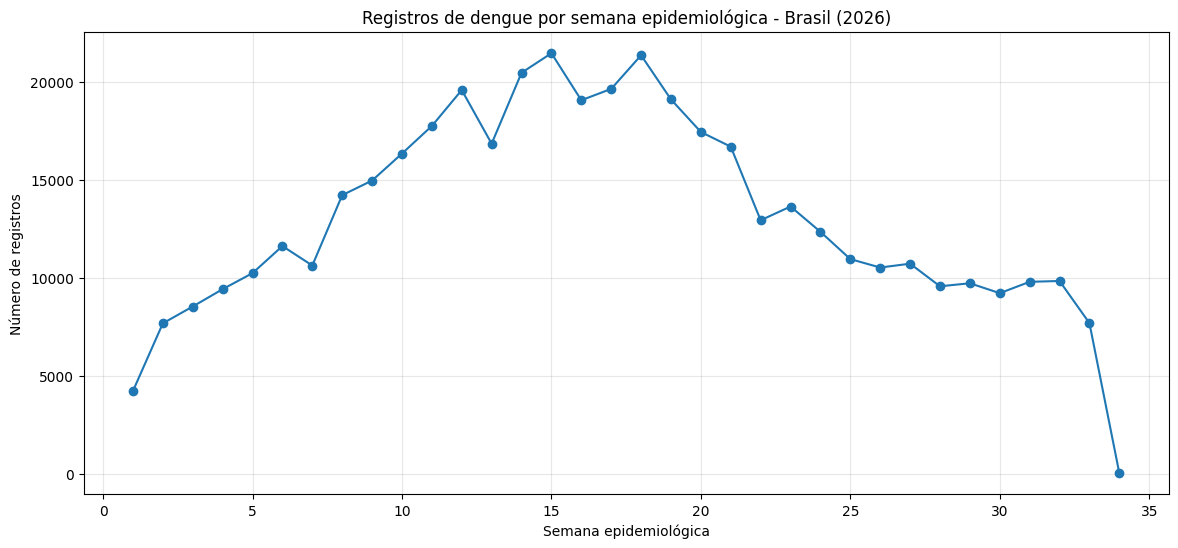

In [19]:
import matplotlib.pyplot as plt

# ============================================================
# SÉRIE TEMPORAL NACIONAL
# ============================================================

plt.figure(
    figsize=(14,6)
)

plt.plot(
    serie_temporal_brasil[
        "SEMANA_EPIDEMIOLOGICA"
    ],
    serie_temporal_brasil[
        "TOTAL_REGISTROS"
    ],
    marker="o"
)

plt.title(
    f"Registros de dengue por semana epidemiológica - Brasil ({ANO})"
)

plt.xlabel(
    "Semana epidemiológica"
)

plt.ylabel(
    "Número de registros"
)

plt.grid(
    alpha=0.3
)

plt.show()

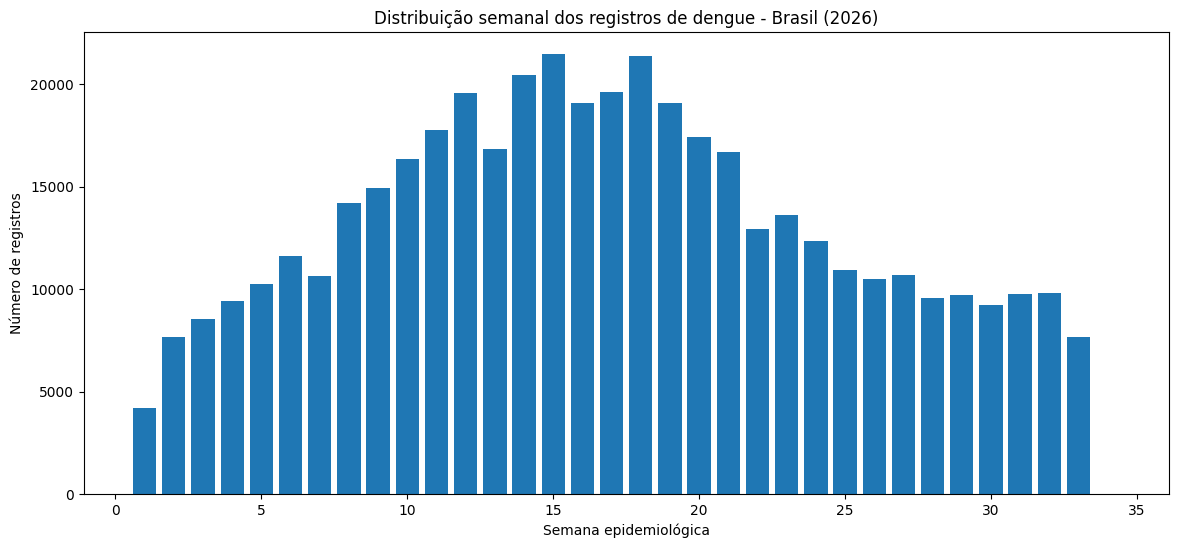

In [20]:
# ============================================================
# DISTRIBUIÇÃO SEMANAL
# ============================================================

plt.figure(
    figsize=(14,6)
)

plt.bar(
    serie_temporal_brasil[
        "SEMANA_EPIDEMIOLOGICA"
    ],
    serie_temporal_brasil[
        "TOTAL_REGISTROS"
    ]
)

plt.title(
    f"Distribuição semanal dos registros de dengue - Brasil ({ANO})"
)

plt.xlabel(
    "Semana epidemiológica"
)

plt.ylabel(
    "Número de registros"
)

plt.show()

### Interpretação

O gráfico apresenta a distribuição dos registros de dengue segundo a
semana epidemiológica de notificação.

Cada ponto representa o total de registros observados em determinada
semana epidemiológica do período analisado.

Picos na série indicam semanas com maior volume de notificações,
enquanto reduções podem refletir diminuição da ocorrência dos casos,
atrasos de notificação ou efeitos do calendário epidemiológico.

Os resultados representam a distribuição temporal dos registros
presentes na base analisada e não devem ser interpretados isoladamente
como medidas de incidência ou transmissão da doença.

In [21]:
# ============================================================
# VALIDAÇÃO DA SÉRIE TEMPORAL
# ============================================================

assert (
    serie_temporal_brasil[
        "TOTAL_REGISTROS"
    ].sum()
    ==
    len(df_temporal)
)

print(
    "OK — série temporal nacional validada."
)

OK — série temporal nacional validada.


## 7 — Distribuição semanal dos registros por UF

In [22]:
# ============================================================
# 7 — DISTRIBUIÇÃO SEMANAL DOS REGISTROS POR UF
# ============================================================

serie_temporal_uf = (
    df_temporal
    .groupby(
        [
            "SG_UF_NOT",
            "UF_NAME",
            "SEMANA_EPIDEMIOLOGICA"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_REGISTROS"
    )
    .sort_values(
        [
            "SG_UF_NOT",
            "SEMANA_EPIDEMIOLOGICA"
        ]
    )
)

display(
    serie_temporal_uf.head(50)
)

,SG_UF_NOT,UF_NAME,SEMANA_EPIDEMIOLOGICA,TOTAL_REGISTROS
0,11,Rondônia,1,22
1,11,Rondônia,2,40
2,11,Rondônia,3,34
3,11,Rondônia,4,50
4,11,Rondônia,5,56
5,11,Rondônia,6,49
6,11,Rondônia,7,34
7,11,Rondônia,8,56
8,11,Rondônia,9,56
9,11,Rondônia,10,50


In [23]:
# ============================================================
# VERIFICAÇÃO DAS UFs
# ============================================================

ufs_temporais = (
    df_temporal[
        [
            "SG_UF_NOT",
            "UF_NAME"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "SG_UF_NOT"
    )
    .reset_index(
        drop=True
    )
)

display(
    ufs_temporais
)

print(
    f"Quantidade de UFs: "
    f"{len(ufs_temporais)}"
)

,SG_UF_NOT,UF_NAME
0,11,Rondônia
1,12,Acre
2,13,Amazonas
3,14,Roraima
4,15,Pará
5,16,Amapá
6,17,Tocantins
7,21,Maranhão
8,22,Piauí
9,23,Ceará


Quantidade de UFs: 27


Criar todas as combinações UF × semana

Esse passo é importante.

Imagine que uma UF não tenha nenhum registro na semana 5. O groupby() simplesmente não criaria uma linha para essa semana.

Para uma série temporal correta, queremos:

SE 4    150

SE 5      0

SE 6    173

**e não:**

SE 4    150

SE 6    173

In [24]:
# ============================================================
# TODAS AS COMBINAÇÕES UF × SEMANA
# ============================================================

semanas_temporais = pd.DataFrame({
    "SEMANA_EPIDEMIOLOGICA": range(
        SEMANA_INICIAL,
        SEMANA_FINAL + 1
    )
})

ufs_temporais["_KEY"] = 1
semanas_temporais["_KEY"] = 1

grade_uf_semana = (
    ufs_temporais
    .merge(
        semanas_temporais,
        on="_KEY"
    )
    .drop(
        columns="_KEY"
    )
)

print(
    f"Combinações UF × semana: "
    f"{len(grade_uf_semana):,}"
)

display(
    grade_uf_semana.head(40)
)

Combinações UF × semana: 918


,SG_UF_NOT,UF_NAME,SEMANA_EPIDEMIOLOGICA
0,11,Rondônia,1
1,11,Rondônia,2
2,11,Rondônia,3
3,11,Rondônia,4
4,11,Rondônia,5
5,11,Rondônia,6
6,11,Rondônia,7
7,11,Rondônia,8
8,11,Rondônia,9
9,11,Rondônia,10


Por exemplo, se houver 27 UFs e 31 semanas:

$$ 27\times31=837 $$

linhas.

Completar semanas sem registros

Agora juntamos a grade completa com a série observada:

In [25]:
# ============================================================
# COMPLETAR A SÉRIE TEMPORAL POR UF
# ============================================================

serie_temporal_uf_completa = (
    grade_uf_semana
    .merge(
        serie_temporal_uf,
        on=[
            "SG_UF_NOT",
            "UF_NAME",
            "SEMANA_EPIDEMIOLOGICA"
        ],
        how="left"
    )
)

serie_temporal_uf_completa[
    "TOTAL_REGISTROS"
] = (
    serie_temporal_uf_completa[
        "TOTAL_REGISTROS"
    ]
    .fillna(0)
    .astype(int)
)

serie_temporal_uf_completa = (
    serie_temporal_uf_completa
    .sort_values(
        [
            "SG_UF_NOT",
            "SEMANA_EPIDEMIOLOGICA"
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    serie_temporal_uf_completa.head(50)
)

,SG_UF_NOT,UF_NAME,SEMANA_EPIDEMIOLOGICA,TOTAL_REGISTROS
0,11,Rondônia,1,22
1,11,Rondônia,2,40
2,11,Rondônia,3,34
3,11,Rondônia,4,50
4,11,Rondônia,5,56
5,11,Rondônia,6,49
6,11,Rondônia,7,34
7,11,Rondônia,8,56
8,11,Rondônia,9,56
9,11,Rondônia,10,50


Validar o número de semanas por UF

Todas as UFs devem possuir o mesmo número de semanas:

In [26]:
# ============================================================
# NÚMERO DE SEMANAS POR UF
# ============================================================

semanas_por_uf = (
    serie_temporal_uf_completa
    .groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ]
    )[
        "SEMANA_EPIDEMIOLOGICA"
    ]
    .nunique()
    .reset_index(
        name="TOTAL_SEMANAS"
    )
)

display(
    semanas_por_uf
)

,SG_UF_NOT,UF_NAME,TOTAL_SEMANAS
0,11,Rondônia,34
1,12,Acre,34
2,13,Amazonas,34
3,14,Roraima,34
4,15,Pará,34
5,16,Amapá,34
6,17,Tocantins,34
7,21,Maranhão,34
8,22,Piauí,34
9,23,Ceará,34


In [27]:
total_semanas_esperadas = (
    SEMANA_FINAL
    -
    SEMANA_INICIAL
    +
    1
)

assert (
    semanas_por_uf[
        "TOTAL_SEMANAS"
    ]
    .eq(
        total_semanas_esperadas
    )
    .all()
), (
    "Existem UFs com série temporal incompleta."
)

print(
    f"OK — todas as UFs possuem "
    f"{total_semanas_esperadas} semanas."
)

OK — todas as UFs possuem 34 semanas.


In [28]:
# ============================================================
# TOTAL DE REGISTROS POR UF NA SÉRIE TEMPORAL
# ============================================================

total_temporal_uf = (
    serie_temporal_uf_completa
    .groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ]
    )[
        "TOTAL_REGISTROS"
    ]
    .sum()
    .reset_index(
        name="TOTAL_REGISTROS"
    )
    .sort_values(
        "TOTAL_REGISTROS",
        ascending=False
    )
)

display(
    total_temporal_uf
)

,SG_UF_NOT,UF_NAME,TOTAL_REGISTROS
25,52,Goiás,108884
19,35,São Paulo,65195
16,31,Minas Gerais,61248
12,26,Pernambuco,22036
15,29,Bahia,21609
17,32,Espírito Santo,19414
8,22,Piauí,17383
9,23,Ceará,17337
6,17,Tocantins,15430
7,21,Maranhão,12282


In [30]:
#Média semanal por UF

#Agora começamos a extrair indicadores:

In [31]:
# ============================================================
# MÉDIA SEMANAL POR UF
# ============================================================

media_semanal_uf = (
    serie_temporal_uf_completa
    .groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ]
    )[
        "TOTAL_REGISTROS"
    ]
    .mean()
    .reset_index(
        name="MEDIA_SEMANAL"
    )
)

media_semanal_uf[
    "MEDIA_SEMANAL"
] = (
    media_semanal_uf[
        "MEDIA_SEMANAL"
    ]
    .round(2)
)

display(
    media_semanal_uf
    .sort_values(
        "MEDIA_SEMANAL",
        ascending=False
    )
)

,SG_UF_NOT,UF_NAME,MEDIA_SEMANAL
25,52,Goiás,3202.47
19,35,São Paulo,1917.50
16,31,Minas Gerais,1801.41
12,26,Pernambuco,648.12
15,29,Bahia,635.56
17,32,Espírito Santo,571.00
8,22,Piauí,511.26
9,23,Ceará,509.91
6,17,Tocantins,453.82
7,21,Maranhão,361.24


Esse indicador significa:

número médio de registros por semana epidemiológica em cada UF durante a janela analisada.

Não é incidência média.

Semana de pico por UF

Vamos identificar a semana com maior número de registros para cada UF

In [32]:
# ============================================================
# SEMANA DE PICO POR UF
# ============================================================

indices_pico_uf = (
    serie_temporal_uf_completa
    .groupby(
        "SG_UF_NOT"
    )[
        "TOTAL_REGISTROS"
    ]
    .idxmax()
)

pico_uf = (
    serie_temporal_uf_completa
    .loc[
        indices_pico_uf,
        [
            "SG_UF_NOT",
            "UF_NAME",
            "SEMANA_EPIDEMIOLOGICA",
            "TOTAL_REGISTROS"
        ]
    ]
    .rename(
        columns={
            "SEMANA_EPIDEMIOLOGICA":
                "SEMANA_PICO",

            "TOTAL_REGISTROS":
                "TOTAL_PICO"
        }
    )
    .sort_values(
        "TOTAL_PICO",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    pico_uf
)

,SG_UF_NOT,UF_NAME,SEMANA_PICO,TOTAL_PICO
0,52,Goiás,15,5568
1,31,Minas Gerais,15,3698
2,35,São Paulo,18,3581
3,23,Ceará,29,1447
4,32,Espírito Santo,17,1170
5,26,Pernambuco,23,1169
6,22,Piauí,21,1131
7,29,Bahia,20,1110
8,17,Tocantins,8,761
9,21,Maranhão,14,724


Consolidar um resumo temporal básico por UF

Embora o passo 8 vá aprofundar os indicadores, já podemos consolidar os três elementos fundamentais:

- total;
- média semanal;
- pico.

In [33]:
# ============================================================
# RESUMO TEMPORAL BÁSICO POR UF
# ============================================================

resumo_temporal_uf = (
    total_temporal_uf
    .merge(
        media_semanal_uf,
        on=[
            "SG_UF_NOT",
            "UF_NAME"
        ],
        how="left"
    )
    .merge(
        pico_uf,
        on=[
            "SG_UF_NOT",
            "UF_NAME"
        ],
        how="left"
    )
)

resumo_temporal_uf[
    "SEMANA_INICIAL"
] = SEMANA_INICIAL

resumo_temporal_uf[
    "SEMANA_FINAL"
] = SEMANA_FINAL

resumo_temporal_uf[
    "ANO"
] = ANO

In [34]:
resumo_temporal_uf = resumo_temporal_uf[
    [
        "ANO",
        "SG_UF_NOT",
        "UF_NAME",
        "SEMANA_INICIAL",
        "SEMANA_FINAL",
        "TOTAL_REGISTROS",
        "MEDIA_SEMANAL",
        "SEMANA_PICO",
        "TOTAL_PICO"
    ]
]

display(
    resumo_temporal_uf
    .sort_values(
        "TOTAL_REGISTROS",
        ascending=False
    )
)

,ANO,SG_UF_NOT,UF_NAME,SEMANA_INICIAL,SEMANA_FINAL,TOTAL_REGISTROS,MEDIA_SEMANAL,SEMANA_PICO,TOTAL_PICO
0,2026,52,Goiás,1,34,108884,3202.47,15,5568
1,2026,35,São Paulo,1,34,65195,1917.50,18,3581
2,2026,31,Minas Gerais,1,34,61248,1801.41,15,3698
3,2026,26,Pernambuco,1,34,22036,648.12,23,1169
4,2026,29,Bahia,1,34,21609,635.56,20,1110
5,2026,32,Espírito Santo,1,34,19414,571.00,17,1170
6,2026,22,Piauí,1,34,17383,511.26,21,1131
7,2026,23,Ceará,1,34,17337,509.91,29,1447
8,2026,17,Tocantins,1,34,15430,453.82,8,761
9,2026,21,Maranhão,1,34,12282,361.24,14,724


Visualizar uma UF específica

Antes de criar gráficos comparativos, vale ter uma célula que permita inspecionar qualquer UF.

Por exemplo:

In [35]:
# ============================================================
# INSPEÇÃO DA SÉRIE TEMPORAL DE UMA UF
# ============================================================

UF_EXEMPLO = "São Paulo"

serie_uf_exemplo = (
    serie_temporal_uf_completa[
        serie_temporal_uf_completa[
            "UF_NAME"
        ].eq(UF_EXEMPLO)
    ]
)

display(
    serie_uf_exemplo
)

,SG_UF_NOT,UF_NAME,SEMANA_EPIDEMIOLOGICA,TOTAL_REGISTROS
646,35,São Paulo,1,1024
647,35,São Paulo,2,1684
648,35,São Paulo,3,1758
649,35,São Paulo,4,1784
650,35,São Paulo,5,1819
651,35,São Paulo,6,2032
652,35,São Paulo,7,2100
653,35,São Paulo,8,2562
654,35,São Paulo,9,2625
655,35,São Paulo,10,2525


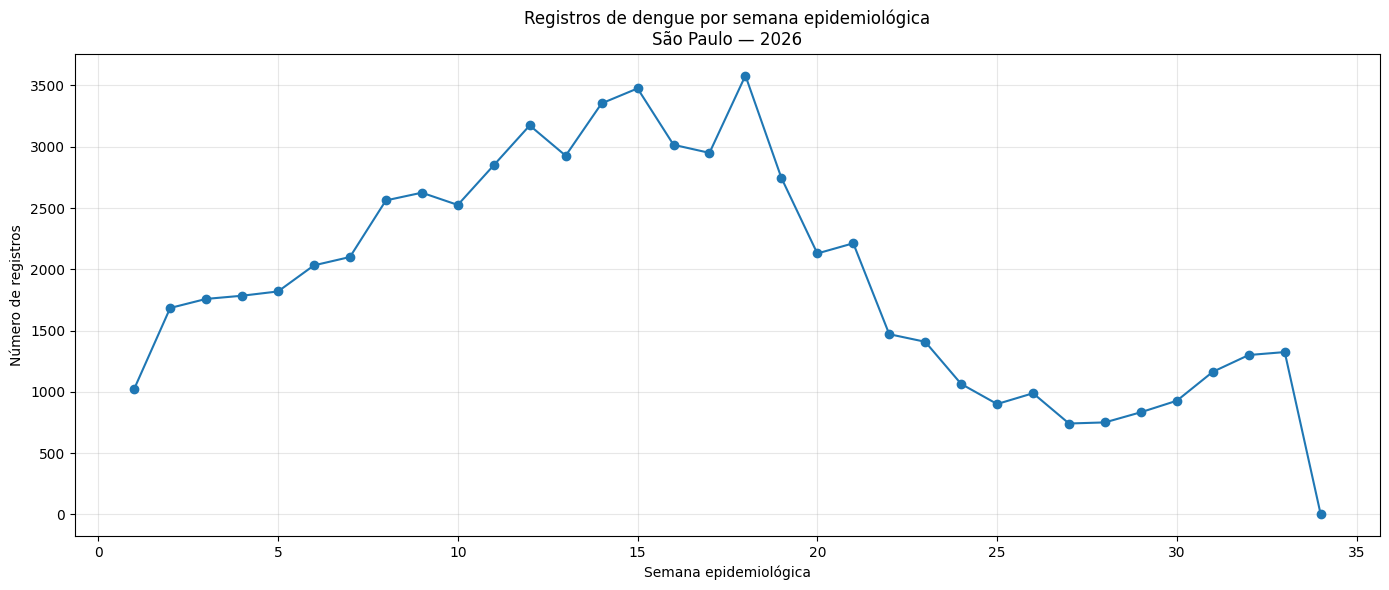

In [36]:
fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.plot(
    serie_uf_exemplo[
        "SEMANA_EPIDEMIOLOGICA"
    ],
    serie_uf_exemplo[
        "TOTAL_REGISTROS"
    ],
    marker="o"
)

ax.set_title(
    f"Registros de dengue por semana epidemiológica\n"
    f"{UF_EXEMPLO} — {ANO}"
)

ax.set_xlabel(
    "Semana epidemiológica"
)

ax.set_ylabel(
    "Número de registros"
)

ax.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Interpretação

O gráfico apresenta a evolução semanal dos registros de dengue para a
UF selecionada, considerando a semana epidemiológica de notificação.

Cada ponto corresponde ao número de registros observados em uma semana
epidemiológica. A série permite identificar períodos de aumento, redução
e maior concentração de notificações, bem como a semana em que ocorreu
o maior número de registros no período analisado.

Os valores representam contagens de registros do SINAN e não taxas de
incidência. Portanto, comparações diretas entre UFs devem considerar
diferenças populacionais e outras características territoriais.

Validações finais

Temos algumas verificações importantes.

Primeiro, a soma de todas as séries estaduais deve reconstruir a série nacional:

In [37]:
# ============================================================
# VALIDAÇÃO — TOTAL DE REGISTROS
# ============================================================

assert (
    serie_temporal_uf_completa[
        "TOTAL_REGISTROS"
    ].sum()
    ==
    serie_temporal_brasil[
        "TOTAL_REGISTROS"
    ].sum()
), (
    "A soma das séries estaduais não corresponde "
    "ao total da série nacional."
)

print(
    "OK — soma das séries estaduais corresponde "
    "à série nacional."
)

OK — soma das séries estaduais corresponde à série nacional.


E deve corresponder ao df_temporal:

In [38]:
assert (
    serie_temporal_uf_completa[
        "TOTAL_REGISTROS"
    ].sum()
    ==
    len(df_temporal)
), (
    "A série temporal por UF não reconstrói "
    "a base temporal."
)

print(
    "OK — série temporal por UF validada."
)

OK — série temporal por UF validada.


Também verificamos se há duplicação de UF × semana:

In [39]:
duplicados = (
    serie_temporal_uf_completa
    .duplicated(
        subset=[
            "SG_UF_NOT",
            "SEMANA_EPIDEMIOLOGICA"
        ]
    )
    .sum()
)

print(
    f"Combinações UF × semana duplicadas: "
    f"{duplicados}"
)

assert duplicados == 0

print(
    "OK — não existem combinações UF × semana duplicadas."
)

Combinações UF × semana duplicadas: 0
OK — não existem combinações UF × semana duplicadas.


## 8 — Indicadores temporais por UF

**Estatísticas descritivas por UF**

Partimos de serie_temporal_uf_completa, porque ela contém explicitamente todas as semanas da janela analisada.

In [40]:
# ============================================================
# 8 — INDICADORES TEMPORAIS POR UF
# ============================================================

estatisticas_temporais_uf = (
    serie_temporal_uf_completa
    .groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ]
    )["TOTAL_REGISTROS"]
    .agg(
        TOTAL_REGISTROS="sum",
        MEDIA_SEMANAL="mean",
        MEDIANA_SEMANAL="median",
        MINIMO_SEMANAL="min",
        MAXIMO_SEMANAL="max",
        DESVIO_PADRAO="std"
    )
    .reset_index()
)

display(
    estatisticas_temporais_uf.head()
)

,SG_UF_NOT,UF_NAME,TOTAL_REGISTROS,MEDIA_SEMANAL,MEDIANA_SEMANAL,MINIMO_SEMANAL,MAXIMO_SEMANAL,DESVIO_PADRAO
0,11,Rondônia,1354,39.823529,40.0,0,71,15.246402
1,12,Acre,1832,53.882353,52.5,0,134,23.095014
2,13,Amazonas,1399,41.147059,37.5,0,102,20.661973
3,14,Roraima,556,16.352941,13.0,0,50,12.419150
4,15,Pará,9323,274.205882,279.0,0,446,101.556606


**Calcular a amplitude**

A amplitude mostra a diferença entre o maior e o menor número semanal de registros:

Amplitude= Máximo - Mínimo

In [41]:
# ============================================================
# AMPLITUDE SEMANAL
# ============================================================

estatisticas_temporais_uf[
    "AMPLITUDE_SEMANAL"
] = (
    estatisticas_temporais_uf[
        "MAXIMO_SEMANAL"
    ]
    -
    estatisticas_temporais_uf[
        "MINIMO_SEMANAL"
    ]
)

Por exemplo, se uma UF tiver:

Mínimo = 200

Máximo = 1.500

a amplitude será:

1.300 registros

Ela indica o intervalo observado entre os extremos, mas não informa sozinha como os valores se distribuíram entre eles.

**Coeficiente de variação**

O desvio-padrão depende da magnitude da série. Uma UF com milhares de registros naturalmente tende a apresentar um desvio-padrão maior que uma UF com poucas dezenas.

Por isso, podemos calcular também:

CV= [(Desvio-padrão)/Média semanal]  x 100

In [42]:
# ============================================================
# COEFICIENTE DE VARIAÇÃO
# ============================================================

estatisticas_temporais_uf[
    "COEFICIENTE_VARIACAO"
] = np.where(
    estatisticas_temporais_uf[
        "MEDIA_SEMANAL"
    ] > 0,

    (
        estatisticas_temporais_uf[
            "DESVIO_PADRAO"
        ]
        /
        estatisticas_temporais_uf[
            "MEDIA_SEMANAL"
        ]
        * 100
    ),

    np.nan
)

O coeficiente de variação permite comparar a variabilidade relativa das séries.

Por exemplo:

**UF A:**

média = 1.000

desvio = 100

CV = 10%

**UF B:**

média = 100

desvio = 50

CV = 50%

Embora a UF A tenha maior desvio absoluto, a série da UF B apresenta maior variabilidade em relação à própria média.

Eu evitaria criar categorias arbitrárias como "CV baixo", "moderado" ou "alto", a menos que tenhamos uma referência metodológica para esses limites.

Arredondar os indicadores

In [43]:
# ============================================================
# FORMATAÇÃO DOS INDICADORES
# ============================================================

colunas_arredondar = [
    "MEDIA_SEMANAL",
    "MEDIANA_SEMANAL",
    "DESVIO_PADRAO",
    "COEFICIENTE_VARIACAO"
]

estatisticas_temporais_uf[
    colunas_arredondar
] = (
    estatisticas_temporais_uf[
        colunas_arredondar
    ]
    .round(2)
)

display(
    estatisticas_temporais_uf
    .sort_values(
        "TOTAL_REGISTROS",
        ascending=False
    )
)

,SG_UF_NOT,UF_NAME,TOTAL_REGISTROS,MEDIA_SEMANAL,MEDIANA_SEMANAL,MINIMO_SEMANAL,MAXIMO_SEMANAL,DESVIO_PADRAO,AMPLITUDE_SEMANAL,COEFICIENTE_VARIACAO
25,52,Goiás,108884,3202.47,3136.5,0,5568,1621.69,5568,50.64
19,35,São Paulo,65195,1917.50,1801.5,0,3581,937.84,3581,48.91
16,31,Minas Gerais,61248,1801.41,1401.5,0,3698,1082.27,3698,60.08
12,26,Pernambuco,22036,648.12,714.5,0,1169,343.80,1169,53.05
15,29,Bahia,21609,635.56,697.0,0,1110,312.37,1110,49.15
17,32,Espírito Santo,19414,571.00,561.0,16,1170,282.69,1154,49.51
8,22,Piauí,17383,511.26,483.5,0,1131,347.91,1131,68.05
9,23,Ceará,17337,509.91,285.5,0,1447,475.00,1447,93.15
6,17,Tocantins,15430,453.82,483.5,0,761,222.42,761,49.01
7,21,Maranhão,12282,361.24,380.5,0,724,207.73,724,57.51


Incorporar a semana de pico

O MAXIMO_SEMANAL nos diz quantos registros houve no máximo, mas não quando isso ocorreu.

Já temos essa informação em pico_uf.

Podemos incorporá-la

In [44]:
# ============================================================
# INCORPORAR A SEMANA DE PICO
# ============================================================

indicadores_temporais_uf = (
    estatisticas_temporais_uf
    .merge(
        pico_uf[
            [
                "SG_UF_NOT",
                "UF_NAME",
                "SEMANA_PICO",
                "TOTAL_PICO"
            ]
        ],
        on=[
            "SG_UF_NOT",
            "UF_NAME"
        ],
        how="left"
    )
)

Como TOTAL_PICO deve ser igual a MAXIMO_SEMANAL, isso também nos dá uma oportunidade de validação.

Adicionar a janela temporal

In [45]:
# ============================================================
# IDENTIFICAÇÃO DA JANELA TEMPORAL
# ============================================================

indicadores_temporais_uf[
    "ANO"
] = ANO

indicadores_temporais_uf[
    "SEMANA_INICIAL"
] = SEMANA_INICIAL

indicadores_temporais_uf[
    "SEMANA_FINAL"
] = SEMANA_FINAL

indicadores_temporais_uf[
    "TOTAL_SEMANAS"
] = (
    SEMANA_FINAL
    -
    SEMANA_INICIAL
    +
    1
)

Depois reorganizamos:

In [46]:
indicadores_temporais_uf = (
    indicadores_temporais_uf[
        [
            "ANO",
            "SG_UF_NOT",
            "UF_NAME",
            "SEMANA_INICIAL",
            "SEMANA_FINAL",
            "TOTAL_SEMANAS",
            "TOTAL_REGISTROS",
            "MEDIA_SEMANAL",
            "MEDIANA_SEMANAL",
            "MINIMO_SEMANAL",
            "MAXIMO_SEMANAL",
            "SEMANA_PICO",
            "TOTAL_PICO",
            "DESVIO_PADRAO",
            "AMPLITUDE_SEMANAL",
            "COEFICIENTE_VARIACAO"
        ]
    ]
    .sort_values(
        "TOTAL_REGISTROS",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    indicadores_temporais_uf
)

,ANO,SG_UF_NOT,UF_NAME,SEMANA_INICIAL,SEMANA_FINAL,TOTAL_SEMANAS,TOTAL_REGISTROS,MEDIA_SEMANAL,MEDIANA_SEMANAL,MINIMO_SEMANAL,MAXIMO_SEMANAL,SEMANA_PICO,TOTAL_PICO,DESVIO_PADRAO,AMPLITUDE_SEMANAL,COEFICIENTE_VARIACAO
0,2026,52,Goiás,1,34,34,108884,3202.47,3136.5,0,5568,15,5568,1621.69,5568,50.64
1,2026,35,São Paulo,1,34,34,65195,1917.50,1801.5,0,3581,18,3581,937.84,3581,48.91
2,2026,31,Minas Gerais,1,34,34,61248,1801.41,1401.5,0,3698,15,3698,1082.27,3698,60.08
3,2026,26,Pernambuco,1,34,34,22036,648.12,714.5,0,1169,23,1169,343.80,1169,53.05
4,2026,29,Bahia,1,34,34,21609,635.56,697.0,0,1110,20,1110,312.37,1110,49.15
5,2026,32,Espírito Santo,1,34,34,19414,571.00,561.0,16,1170,17,1170,282.69,1154,49.51
6,2026,22,Piauí,1,34,34,17383,511.26,483.5,0,1131,21,1131,347.91,1131,68.05
7,2026,23,Ceará,1,34,34,17337,509.91,285.5,0,1447,29,1447,475.00,1447,93.15
8,2026,17,Tocantins,1,34,34,15430,453.82,483.5,0,761,8,761,222.42,761,49.01
9,2026,21,Maranhão,1,34,34,12282,361.24,380.5,0,724,14,724,207.73,724,57.51


Esse DataFrame passa a ser um dos principais produtos do notebook 05_5.

### Interpretação dos indicadores temporais

Os indicadores sintetizam o comportamento semanal dos registros de dengue
em cada UF durante a janela epidemiológica analisada.

- **Total de registros:** quantidade acumulada de registros na UF durante
  o período analisado.
- **Média semanal:** número médio de registros por semana epidemiológica.
- **Mediana semanal:** valor central da distribuição semanal, menos
  sensível a semanas com valores extremos.
- **Mínimo semanal:** menor número de registros observado em uma semana.
- **Máximo semanal:** maior número de registros observado em uma semana.
- **Semana de pico:** semana epidemiológica em que foi observado o maior
  número de registros.
- **Desvio-padrão:** representa a dispersão das contagens semanais em
  relação à média.
- **Amplitude semanal:** diferença entre o maior e o menor número de
  registros semanais.
- **Coeficiente de variação:** expressa a variabilidade relativa das
  contagens semanais em relação à média da própria UF.

Esses indicadores caracterizam o comportamento temporal dos registros
disponíveis no SINAN. Valores elevados de variabilidade ou a presença de
picos não devem ser interpretados isoladamente como evidência de aumento
da transmissão, pois também podem ser influenciados pelo processo de
notificação e pela atualização da base.

Ranking das UFs pela média semanal

Para inspeção:

In [47]:
# ============================================================
# UFs COM MAIOR MÉDIA SEMANAL DE REGISTROS
# ============================================================

display(
    indicadores_temporais_uf[
        [
            "UF_NAME",
            "TOTAL_REGISTROS",
            "MEDIA_SEMANAL",
            "SEMANA_PICO",
            "TOTAL_PICO"
        ]
    ]
    .sort_values(
        "MEDIA_SEMANAL",
        ascending=False
    )
)

,UF_NAME,TOTAL_REGISTROS,MEDIA_SEMANAL,SEMANA_PICO,TOTAL_PICO
0,Goiás,108884,3202.47,15,5568
1,São Paulo,65195,1917.50,18,3581
2,Minas Gerais,61248,1801.41,15,3698
3,Pernambuco,22036,648.12,23,1169
4,Bahia,21609,635.56,20,1110
5,Espírito Santo,19414,571.00,17,1170
6,Piauí,17383,511.26,21,1131
7,Ceará,17337,509.91,29,1447
8,Tocantins,15430,453.82,8,761
9,Maranhão,12282,361.24,14,724


Esse ranking provavelmente ficará muito parecido com o total acumulado, porque todas as UFs possuem a mesma quantidade de semanas.

Portanto, não considero necessário transformá-lo em um produto separado.

UFs com maior variabilidade relativa

Essa análise é mais interessante:

In [48]:
# ============================================================
# VARIABILIDADE RELATIVA DAS SÉRIES
# ============================================================

display(
    indicadores_temporais_uf[
        [
            "UF_NAME",
            "MEDIA_SEMANAL",
            "DESVIO_PADRAO",
            "COEFICIENTE_VARIACAO"
        ]
    ]
    .sort_values(
        "COEFICIENTE_VARIACAO",
        ascending=False
    )
)

,UF_NAME,MEDIA_SEMANAL,DESVIO_PADRAO,COEFICIENTE_VARIACAO
24,Sergipe,34.26,33.00,96.30
7,Ceará,509.91,475.00,93.15
25,Roraima,16.35,12.42,75.94
15,Rio Grande do Sul,198.32,146.14,73.69
17,Alagoas,160.97,113.36,70.42
6,Piauí,511.26,347.91,68.05
20,Santa Catarina,90.29,56.69,62.78
2,Minas Gerais,1801.41,1082.27,60.08
18,Mato Grosso do Sul,136.79,81.38,59.49
9,Maranhão,361.24,207.73,57.51


Isso permite identificar UFs cujas notificações apresentaram maior oscilação proporcional ao próprio volume semanal.

Mas novamente: CV elevado não significa maior risco epidemiológico.

**Distribuição das semanas de pico**

Podemos fazer uma análise agregada interessante: verificar quantas UFs atingiram seu pico em cada semana epidemiológica.

In [49]:
# ============================================================
# DISTRIBUIÇÃO DAS SEMANAS DE PICO ENTRE AS UFs
# ============================================================

distribuicao_picos_uf = (
    pico_uf
    .groupby(
        "SEMANA_PICO"
    )
    .size()
    .reset_index(
        name="TOTAL_UFS"
    )
    .sort_values(
        "SEMANA_PICO"
    )
)

display(
    distribuicao_picos_uf
)

,SEMANA_PICO,TOTAL_UFS
0,8,1
1,12,3
2,14,2
3,15,4
4,17,1
5,18,2
6,20,1
7,21,1
8,23,2
9,26,1


Isso pode responder:

Em quais semanas epidemiológicas ocorreu o pico de notificações de um maior número de UFs?

Esse é um produto temporal interessante e diferente de simplesmente contar registros.

Identificar a semana mais frequente de pico

In [50]:
indice = (
    distribuicao_picos_uf[
        "TOTAL_UFS"
    ]
    .idxmax()
)

semana_pico_mais_frequente = int(
    distribuicao_picos_uf.loc[
        indice,
        "SEMANA_PICO"
    ]
)

total_ufs_pico = int(
    distribuicao_picos_uf.loc[
        indice,
        "TOTAL_UFS"
    ]
)

print(
    f"Semana com maior número de UFs atingindo pico: "
    f"SE {semana_pico_mais_frequente}"
)

print(
    f"Quantidade de UFs: "
    f"{total_ufs_pico}"
)

Semana com maior número de UFs atingindo pico: SE 15
Quantidade de UFs: 4


Aqui devemos falar:

“semana em que o maior número de UFs apresentou seu máximo de registros no período”.

Não:

“pico nacional da epidemia”.

São conceitos diferentes.

Validações

Primeiro, MAXIMO_SEMANAL deve ser igual ao TOTAL_PICO:

In [51]:
# ============================================================
# VALIDAÇÃO — VALOR DO PICO
# ============================================================

assert (
    indicadores_temporais_uf[
        "MAXIMO_SEMANAL"
    ]
    ==
    indicadores_temporais_uf[
        "TOTAL_PICO"
    ]
).all(), (
    "Existem divergências entre o máximo semanal "
    "e o total da semana de pico."
)

print(
    "OK — valores de pico consistentes."
)

OK — valores de pico consistentes.


Cada UF deve aparecer uma única vez:

In [52]:
assert (
    indicadores_temporais_uf[
        "SG_UF_NOT"
    ].nunique()
    ==
    len(ufs_temporais)
), (
    "Quantidade de UFs nos indicadores "
    "difere da série temporal."
)

assert (
    len(indicadores_temporais_uf)
    ==
    len(ufs_temporais)
), (
    "Existem UFs duplicadas nos indicadores."
)

print(
    "OK — indicadores temporais possuem "
    "uma linha por UF."
)

OK — indicadores temporais possuem uma linha por UF.


In [53]:
assert (
    indicadores_temporais_uf[
        "TOTAL_REGISTROS"
    ].sum()
    ==
    len(df_temporal)
), (
    "Os indicadores por UF não reconstroem "
    "o total da base temporal."
)

print(
    "OK — indicadores temporais validados."
)

OK — indicadores temporais validados.


# 9 — Janela recente e variação temporal.

- janela recente: últimas 4 semanas disponíveis;

- janela anterior: 4 semanas imediatamente anteriores.

Assim, se a última semana disponível for a SE 31:

- anterior: SE 24–27;

- recente: SE 28–31.

Isso permite comparar períodos de mesma duração.

In [54]:
# ============================================================
# 9 — JANELA RECENTE E VARIAÇÃO TEMPORAL
# ============================================================

TAMANHO_JANELA = 4

SEMANA_FINAL_RECENTE = SEMANA_FINAL

SEMANA_INICIAL_RECENTE = (
    SEMANA_FINAL_RECENTE
    - TAMANHO_JANELA
    + 1
)

SEMANA_FINAL_ANTERIOR = (
    SEMANA_INICIAL_RECENTE
    - 1
)

SEMANA_INICIAL_ANTERIOR = (
    SEMANA_FINAL_ANTERIOR
    - TAMANHO_JANELA
    + 1
)

print(
    f"Janela anterior: "
    f"SE {SEMANA_INICIAL_ANTERIOR} "
    f"a SE {SEMANA_FINAL_ANTERIOR}"
)

print(
    f"Janela recente: "
    f"SE {SEMANA_INICIAL_RECENTE} "
    f"a SE {SEMANA_FINAL_RECENTE}"
)

Janela anterior: SE 27 a SE 30
Janela recente: SE 31 a SE 34


### Definição das janelas temporais

Para caracterizar o comportamento temporal recente dos registros, foram
consideradas duas janelas consecutivas de quatro semanas epidemiológicas.

A janela recente corresponde às quatro últimas semanas disponíveis na
base, enquanto a janela anterior corresponde às quatro semanas
imediatamente anteriores.

A utilização de janelas de mesma duração permite comparar o volume médio
semanal de registros entre dois períodos consecutivos, reduzindo a
influência de oscilações observadas em uma única semana.

A escolha de quatro semanas constitui uma decisão operacional desta
análise e não representa, por si só, um limiar epidemiológico para
caracterização de tendências ou surtos.

**Validar se existem semanas suficientes**

Antes de calcular qualquer coisa:

In [55]:
# ============================================================
# VALIDAÇÃO DAS JANELAS
# ============================================================

total_semanas_disponiveis = (
    SEMANA_FINAL
    - SEMANA_INICIAL
    + 1
)

assert (
    total_semanas_disponiveis
    >=
    2 * TAMANHO_JANELA
), (
    "Número insuficiente de semanas para "
    "comparar as duas janelas temporais."
)

print(
    "OK — existem semanas suficientes "
    "para comparação das janelas."
)

OK — existem semanas suficientes para comparação das janelas.


**Selecionar a janela anterior**

Vamos partir de serie_temporal_uf_completa.

In [56]:
# ============================================================
# JANELA ANTERIOR
# ============================================================

serie_anterior_uf = (
    serie_temporal_uf_completa[
        serie_temporal_uf_completa[
            "SEMANA_EPIDEMIOLOGICA"
        ].between(
            SEMANA_INICIAL_ANTERIOR,
            SEMANA_FINAL_ANTERIOR
        )
    ]
    .copy()
)

display(
    serie_anterior_uf.head(20)
)

,SG_UF_NOT,UF_NAME,SEMANA_EPIDEMIOLOGICA,TOTAL_REGISTROS
26,11,Rondônia,27,39
27,11,Rondônia,28,40
28,11,Rondônia,29,40
29,11,Rondônia,30,41
60,12,Acre,27,48
61,12,Acre,28,31
62,12,Acre,29,43
63,12,Acre,30,59
94,13,Amazonas,27,56
95,13,Amazonas,28,48


**Selecionar a janela recente**

In [57]:
# ============================================================
# JANELA RECENTE
# ============================================================

serie_recente_uf = (
    serie_temporal_uf_completa[
        serie_temporal_uf_completa[
            "SEMANA_EPIDEMIOLOGICA"
        ].between(
            SEMANA_INICIAL_RECENTE,
            SEMANA_FINAL_RECENTE
        )
    ]
    .copy()
)

display(
    serie_recente_uf.head(20)
)

,SG_UF_NOT,UF_NAME,SEMANA_EPIDEMIOLOGICA,TOTAL_REGISTROS
30,11,Rondônia,31,38
31,11,Rondônia,32,24
32,11,Rondônia,33,11
33,11,Rondônia,34,0
64,12,Acre,31,78
65,12,Acre,32,134
66,12,Acre,33,50
67,12,Acre,34,0
98,13,Amazonas,31,102
99,13,Amazonas,32,86


**Validar as duas janelas**

Cada UF deve ter exatamente quatro semanas em cada período.

In [58]:
# ============================================================
# VALIDAÇÃO DO NÚMERO DE SEMANAS
# ============================================================

semanas_anterior_uf = (
    serie_anterior_uf
    .groupby(
        "SG_UF_NOT"
    )[
        "SEMANA_EPIDEMIOLOGICA"
    ]
    .nunique()
)

semanas_recente_uf = (
    serie_recente_uf
    .groupby(
        "SG_UF_NOT"
    )[
        "SEMANA_EPIDEMIOLOGICA"
    ]
    .nunique()
)

assert (
    semanas_anterior_uf
    .eq(TAMANHO_JANELA)
    .all()
)

assert (
    semanas_recente_uf
    .eq(TAMANHO_JANELA)
    .all()
)

print(
    "OK — todas as UFs possuem "
    f"{TAMANHO_JANELA} semanas em cada janela."
)

OK — todas as UFs possuem 4 semanas em cada janela.


Calcular indicadores da janela anterior

Vamos calcular total e média semanal.

In [59]:
# ============================================================
# INDICADORES — JANELA ANTERIOR
# ============================================================

janela_anterior_uf = (
    serie_anterior_uf
    .groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ]
    )[
        "TOTAL_REGISTROS"
    ]
    .agg(
        TOTAL_ANTERIOR="sum",
        MEDIA_ANTERIOR="mean"
    )
    .reset_index()
)

janela_anterior_uf[
    "MEDIA_ANTERIOR"
] = (
    janela_anterior_uf[
        "MEDIA_ANTERIOR"
    ]
    .round(2)
)

display(
    janela_anterior_uf
)

,SG_UF_NOT,UF_NAME,TOTAL_ANTERIOR,MEDIA_ANTERIOR
0,11,Rondônia,160,40.00
1,12,Acre,181,45.25
2,13,Amazonas,193,48.25
3,14,Roraima,113,28.25
4,15,Pará,883,220.75
5,16,Amapá,68,17.00
6,17,Tocantins,795,198.75
7,21,Maranhão,860,215.00
8,22,Piauí,1752,438.00
9,23,Ceará,5346,1336.50


**Indicadores da janela recente**

In [60]:
# ============================================================
# INDICADORES — JANELA RECENTE
# ============================================================

janela_recente_uf = (
    serie_recente_uf
    .groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ]
    )[
        "TOTAL_REGISTROS"
    ]
    .agg(
        TOTAL_RECENTE="sum",
        MEDIA_RECENTE="mean"
    )
    .reset_index()
)

janela_recente_uf[
    "MEDIA_RECENTE"
] = (
    janela_recente_uf[
        "MEDIA_RECENTE"
    ]
    .round(2)
)

display(
    janela_recente_uf
)

,SG_UF_NOT,UF_NAME,TOTAL_RECENTE,MEDIA_RECENTE
0,11,Rondônia,73,18.25
1,12,Acre,262,65.50
2,13,Amazonas,271,67.75
3,14,Roraima,117,29.25
4,15,Pará,565,141.25
5,16,Amapá,38,9.50
6,17,Tocantins,596,149.00
7,21,Maranhão,167,41.75
8,22,Piauí,509,127.25
9,23,Ceará,2895,723.75


**Comparar as duas janelas**

Agora criamos nosso principal DataFrame deste passo:

In [61]:
# ============================================================
# COMPARAÇÃO DAS JANELAS
# ============================================================

variacao_temporal_uf = (
    janela_anterior_uf
    .merge(
        janela_recente_uf,
        on=[
            "SG_UF_NOT",
            "UF_NAME"
        ],
        how="inner"
    )
)

display(
    variacao_temporal_uf
)

,SG_UF_NOT,UF_NAME,TOTAL_ANTERIOR,MEDIA_ANTERIOR,TOTAL_RECENTE,MEDIA_RECENTE
0,11,Rondônia,160,40.00,73,18.25
1,12,Acre,181,45.25,262,65.50
2,13,Amazonas,193,48.25,271,67.75
3,14,Roraima,113,28.25,117,29.25
4,15,Pará,883,220.75,565,141.25
5,16,Amapá,68,17.00,38,9.50
6,17,Tocantins,795,198.75,596,149.00
7,21,Maranhão,860,215.00,167,41.75
8,22,Piauí,1752,438.00,509,127.25
9,23,Ceará,5346,1336.50,2895,723.75


Variação absoluta

Podemos comparar as médias:

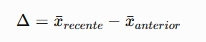

In [62]:
# ============================================================
# VARIAÇÃO ABSOLUTA DA MÉDIA SEMANAL
# ============================================================

variacao_temporal_uf[
    "VARIACAO_ABSOLUTA"
] = (
    variacao_temporal_uf[
        "MEDIA_RECENTE"
    ]
    -
    variacao_temporal_uf[
        "MEDIA_ANTERIOR"
    ]
).round(2)

Exemplo:

Média anterior = 1.000

Média recente  =   800

Variação absoluta = -200 registros/semana

Variação percentual

Calculamos:

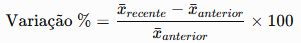

In [63]:
# ============================================================
# VARIAÇÃO PERCENTUAL
# ============================================================

variacao_temporal_uf[
    "VARIACAO_PERCENTUAL"
] = np.where(
    variacao_temporal_uf[
        "MEDIA_ANTERIOR"
    ] > 0,

    (
        variacao_temporal_uf[
            "MEDIA_RECENTE"
        ]
        -
        variacao_temporal_uf[
            "MEDIA_ANTERIOR"
        ]
    )
    /
    variacao_temporal_uf[
        "MEDIA_ANTERIOR"
    ]
    * 100,

    np.nan
)

variacao_temporal_uf[
    "VARIACAO_PERCENTUAL"
] = (
    variacao_temporal_uf[
        "VARIACAO_PERCENTUAL"
    ]
    .round(2)
)

Atenção ao denominador zero

Existe uma situação especial:

Média anterior = 0
Média recente = 15

Não podemos calcular:

$$ \frac{15-0}{0} $$

Por isso usamos NaN.

Mas é útil registrar o motivo:

In [64]:
variacao_temporal_uf[
    "VARIACAO_PERCENTUAL_CALCULAVEL"
] = np.where(
    variacao_temporal_uf[
        "MEDIA_ANTERIOR"
    ] > 0,
    "Sim",
    "Não"
)

Classificação operacional do comportamento recente

Aqui precisamos tomar uma decisão metodológica.

Eu sugiro inicialmente:

LIMIAR_ESTABILIDADE = 10

**Assim:**

acima de +10% → Aumento;

abaixo de −10% → Redução;

entre −10% e +10% → Estável

In [65]:
# ============================================================
# CLASSIFICAÇÃO DO COMPORTAMENTO RECENTE
# ============================================================

LIMIAR_ESTABILIDADE = 10

In [66]:
def classificar_variacao_temporal(valor):

    if pd.isna(valor):
        return "Não classificável"

    elif valor > LIMIAR_ESTABILIDADE:
        return "Aumento"

    elif valor < -LIMIAR_ESTABILIDADE:
        return "Redução"

    else:
        return "Estável"

In [67]:
variacao_temporal_uf[
    "CLASSIFICACAO_VARIACAO"
] = (
    variacao_temporal_uf[
        "VARIACAO_PERCENTUAL"
    ]
    .apply(
        classificar_variacao_temporal
    )
)

Um cuidado importante

Esse 10% não é um limiar epidemiológico oficial. É uma regra operacional para geração de um resumo analítico.

Eu deixaria isso explícito:

### Classificação operacional da variação

Para facilitar a descrição dos resultados, a variação entre as duas
janelas foi classificada operacionalmente em:

- **Aumento:** variação superior a +10%;
- **Estável:** variação entre -10% e +10%;
- **Redução:** variação inferior a -10%;
- **Não classificável:** situações em que a variação percentual não
  pôde ser calculada.

O limiar de 10% é utilizado como critério analítico operacional para
resumir o comportamento das contagens semanais e não corresponde a um
limiar epidemiológico oficial para determinação de tendência, surto ou
aumento da transmissão.

**Acrescentar informações das janelas**

Isso será muito útil no Notebook 06, porque o documento semântico não deverá depender de conhecimento externo sobre quais semanas foram comparadas.

In [68]:
# ============================================================
# METADADOS DAS JANELAS
# ============================================================

variacao_temporal_uf[
    "SEMANA_INICIAL_ANTERIOR"
] = SEMANA_INICIAL_ANTERIOR

variacao_temporal_uf[
    "SEMANA_FINAL_ANTERIOR"
] = SEMANA_FINAL_ANTERIOR

variacao_temporal_uf[
    "SEMANA_INICIAL_RECENTE"
] = SEMANA_INICIAL_RECENTE

variacao_temporal_uf[
    "SEMANA_FINAL_RECENTE"
] = SEMANA_FINAL_RECENTE

variacao_temporal_uf[
    "LIMIAR_ESTABILIDADE_PERCENTUAL"
] = LIMIAR_ESTABILIDADE

**Reorganizar o produto**

In [69]:
variacao_temporal_uf = (
    variacao_temporal_uf[
        [
            "SG_UF_NOT",
            "UF_NAME",

            "SEMANA_INICIAL_ANTERIOR",
            "SEMANA_FINAL_ANTERIOR",

            "SEMANA_INICIAL_RECENTE",
            "SEMANA_FINAL_RECENTE",

            "TOTAL_ANTERIOR",
            "MEDIA_ANTERIOR",

            "TOTAL_RECENTE",
            "MEDIA_RECENTE",

            "VARIACAO_ABSOLUTA",
            "VARIACAO_PERCENTUAL",
            "VARIACAO_PERCENTUAL_CALCULAVEL",

            "CLASSIFICACAO_VARIACAO",
            "LIMIAR_ESTABILIDADE_PERCENTUAL"
        ]
    ]
    .sort_values(
        "VARIACAO_PERCENTUAL",
        ascending=False,
        na_position="last"
    )
    .reset_index(
        drop=True
    )
)

display(
    variacao_temporal_uf
)

,SG_UF_NOT,UF_NAME,SEMANA_INICIAL_ANTERIOR,SEMANA_FINAL_ANTERIOR,SEMANA_INICIAL_RECENTE,SEMANA_FINAL_RECENTE,TOTAL_ANTERIOR,MEDIA_ANTERIOR,TOTAL_RECENTE,MEDIA_RECENTE,VARIACAO_ABSOLUTA,VARIACAO_PERCENTUAL,VARIACAO_PERCENTUAL_CALCULAVEL,CLASSIFICACAO_VARIACAO,LIMIAR_ESTABILIDADE_PERCENTUAL
0,42,Santa Catarina,27,30,31,34,203,50.75,404,101.00,50.25,99.01,Sim,Aumento,10
1,41,Paraná,27,30,31,34,732,183.00,1405,351.25,168.25,91.94,Sim,Aumento,10
2,43,Rio Grande do Sul,27,30,31,34,122,30.50,196,49.00,18.50,60.66,Sim,Aumento,10
3,12,Acre,27,30,31,34,181,45.25,262,65.50,20.25,44.75,Sim,Aumento,10
4,50,Mato Grosso do Sul,27,30,31,34,332,83.00,479,119.75,36.75,44.28,Sim,Aumento,10
5,13,Amazonas,27,30,31,34,193,48.25,271,67.75,19.50,40.41,Sim,Aumento,10
6,53,Distrito Federal,27,30,31,34,362,90.50,446,111.50,21.00,23.20,Sim,Aumento,10
7,35,São Paulo,27,30,31,34,3251,812.75,3787,946.75,134.00,16.49,Sim,Aumento,10
8,14,Roraima,27,30,31,34,113,28.25,117,29.25,1.00,3.54,Sim,Estável,10
9,33,Rio de Janeiro,27,30,31,34,540,135.00,485,121.25,-13.75,-10.19,Sim,Redução,10


Resumo das classificações

Podemos verificar quantas UFs ficaram em cada situação:

In [70]:
# ============================================================
# DISTRIBUIÇÃO DAS CLASSIFICAÇÕES
# ============================================================

resumo_variacao_temporal = (
    variacao_temporal_uf[
        "CLASSIFICACAO_VARIACAO"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "CLASSIFICACAO_VARIACAO"
    )
    .reset_index(
        name="TOTAL_UFS"
    )
)

resumo_variacao_temporal[
    "PERCENTUAL_UFS"
] = (
    resumo_variacao_temporal[
        "TOTAL_UFS"
    ]
    /
    len(variacao_temporal_uf)
    * 100
).round(2)

display(
    resumo_variacao_temporal
)

,CLASSIFICACAO_VARIACAO,TOTAL_UFS,PERCENTUAL_UFS
0,Redução,18,66.67
1,Aumento,8,29.63
2,Estável,1,3.70


**Inspecionar maiores aumentos**

In [71]:
display(
    variacao_temporal_uf[
        [
            "UF_NAME",
            "MEDIA_ANTERIOR",
            "MEDIA_RECENTE",
            "VARIACAO_ABSOLUTA",
            "VARIACAO_PERCENTUAL",
            "CLASSIFICACAO_VARIACAO"
        ]
    ]
    .sort_values(
        "VARIACAO_PERCENTUAL",
        ascending=False
    )
    .head(10)
)

,UF_NAME,MEDIA_ANTERIOR,MEDIA_RECENTE,VARIACAO_ABSOLUTA,VARIACAO_PERCENTUAL,CLASSIFICACAO_VARIACAO
0,Santa Catarina,50.75,101.00,50.25,99.01,Aumento
1,Paraná,183.00,351.25,168.25,91.94,Aumento
2,Rio Grande do Sul,30.50,49.00,18.50,60.66,Aumento
3,Acre,45.25,65.50,20.25,44.75,Aumento
4,Mato Grosso do Sul,83.00,119.75,36.75,44.28,Aumento
5,Amazonas,48.25,67.75,19.50,40.41,Aumento
6,Distrito Federal,90.50,111.50,21.00,23.20,Aumento
7,São Paulo,812.75,946.75,134.00,16.49,Aumento
8,Roraima,28.25,29.25,1.00,3.54,Estável
9,Rio de Janeiro,135.00,121.25,-13.75,-10.19,Redução


Interprete como:

UFs com maior aumento percentual no número médio semanal de registros entre as duas janelas analisadas.

**Não como:**

UFs onde a dengue mais cresceu.

**Inspecionar maiores reduções**

In [72]:
display(
    variacao_temporal_uf[
        [
            "UF_NAME",
            "MEDIA_ANTERIOR",
            "MEDIA_RECENTE",
            "VARIACAO_ABSOLUTA",
            "VARIACAO_PERCENTUAL",
            "CLASSIFICACAO_VARIACAO"
        ]
    ]
    .sort_values(
        "VARIACAO_PERCENTUAL",
        ascending=True
    )
    .head(10)
)

,UF_NAME,MEDIA_ANTERIOR,MEDIA_RECENTE,VARIACAO_ABSOLUTA,VARIACAO_PERCENTUAL,CLASSIFICACAO_VARIACAO
26,Maranhão,215.00,41.75,-173.25,-80.58,Redução
25,Piauí,438.00,127.25,-310.75,-70.95,Redução
24,Rondônia,40.00,18.25,-21.75,-54.37,Redução
23,Pernambuco,934.25,476.00,-458.25,-49.05,Redução
22,Bahia,793.25,417.50,-375.75,-47.37,Redução
21,Ceará,1336.50,723.75,-612.75,-45.85,Redução
20,Amapá,17.00,9.50,-7.50,-44.12,Redução
19,Alagoas,342.50,195.75,-146.75,-42.85,Redução
18,Goiás,1478.00,857.75,-620.25,-41.97,Redução
17,Paraíba,280.00,178.00,-102.00,-36.43,Redução


Da mesma forma, estamos falando de redução nas contagens médias semanais registradas, não necessariamente redução da transmissão.

Validações

Uma UF por linha:

In [73]:
# ============================================================
# VALIDAÇÃO
# ============================================================

assert (
    len(variacao_temporal_uf)
    ==
    len(ufs_temporais)
), (
    "Quantidade de UFs na comparação temporal "
    "difere do esperado."
)

assert (
    variacao_temporal_uf[
        "SG_UF_NOT"
    ].nunique()
    ==
    len(ufs_temporais)
), (
    "Existem UFs duplicadas na comparação temporal."
)

print(
    "OK — uma linha por UF."
)

OK — uma linha por UF.


As janelas devem possuir o mesmo número de semanas:

In [74]:
assert (
    SEMANA_FINAL_ANTERIOR
    - SEMANA_INICIAL_ANTERIOR
    + 1
    ==
    TAMANHO_JANELA
)

assert (
    SEMANA_FINAL_RECENTE
    - SEMANA_INICIAL_RECENTE
    + 1
    ==
    TAMANHO_JANELA
)

print(
    "OK — janelas temporais possuem "
    "a mesma duração."
)

OK — janelas temporais possuem a mesma duração.


E podemos conferir matematicamente a variação absoluta:

In [75]:
assert np.allclose(
    variacao_temporal_uf[
        "VARIACAO_ABSOLUTA"
    ],
    (
        variacao_temporal_uf[
            "MEDIA_RECENTE"
        ]
        -
        variacao_temporal_uf[
            "MEDIA_ANTERIOR"
        ]
    ).round(2),
    equal_nan=True
)

print(
    "OK — variações temporais validadas."
)

OK — variações temporais validadas.


# 10 — Identificação das semanas de pico.

Identificar o valor máximo de cada UF

Partimos novamente de serie_temporal_uf_completa

In [76]:
# ============================================================
# 10 — IDENTIFICAÇÃO DAS SEMANAS DE PICO
# ============================================================

maximo_por_uf = (
    serie_temporal_uf_completa
    .groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ]
    )["TOTAL_REGISTROS"]
    .max()
    .reset_index(
        name="TOTAL_PICO"
    )
)

display(
    maximo_por_uf
)

,SG_UF_NOT,UF_NAME,TOTAL_PICO
0,11,Rondônia,71
1,12,Acre,134
2,13,Amazonas,102
3,14,Roraima,50
4,15,Pará,446
5,16,Amapá,34
6,17,Tocantins,761
7,21,Maranhão,724
8,22,Piauí,1131
9,23,Ceará,1447


Aqui ainda não identificamos a semana. Apenas determinamos o maior número semanal de registros observado em cada UF.

**Identificar todas as semanas de pico**

Agora associamos o máximo à série original:

In [77]:
# ============================================================
# TODAS AS SEMANAS QUE ATINGIRAM O VALOR MÁXIMO
# ============================================================

semanas_pico_uf = (
    serie_temporal_uf_completa
    .merge(
        maximo_por_uf,
        on=[
            "SG_UF_NOT",
            "UF_NAME"
        ],
        how="left"
    )
)

semanas_pico_uf = (
    semanas_pico_uf[
        semanas_pico_uf[
            "TOTAL_REGISTROS"
        ]
        ==
        semanas_pico_uf[
            "TOTAL_PICO"
        ]
    ]
    [
        [
            "SG_UF_NOT",
            "UF_NAME",
            "SEMANA_EPIDEMIOLOGICA",
            "TOTAL_PICO"
        ]
    ]
    .rename(
        columns={
            "SEMANA_EPIDEMIOLOGICA":
                "SEMANA_PICO"
        }
    )
    .sort_values(
        [
            "SG_UF_NOT",
            "SEMANA_PICO"
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    semanas_pico_uf
)

,SG_UF_NOT,UF_NAME,SEMANA_PICO,TOTAL_PICO
0,11,Rondônia,15,71
1,12,Acre,32,134
2,13,Amazonas,31,102
3,14,Roraima,31,50
4,15,Pará,12,446
5,16,Amapá,23,34
6,17,Tocantins,8,761
7,21,Maranhão,14,724
8,22,Piauí,21,1131
9,23,Ceará,29,1447


Agora uma UF pode aparecer mais de uma vez caso tenha ocorrido empate.

Por exemplo:

UF            SEMANA_PICO    TOTAL_PICO

Acre          15             220

Acre          16             220

**Quantidade de semanas de pico por UF**

In [78]:
# ============================================================
# QUANTIDADE DE SEMANAS EMPATADAS NO PICO
# ============================================================

quantidade_picos_uf = (
    semanas_pico_uf
    .groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ]
    )
    .size()
    .reset_index(
        name="QUANTIDADE_SEMANAS_PICO"
    )
)

display(
    quantidade_picos_uf
)

,SG_UF_NOT,UF_NAME,QUANTIDADE_SEMANAS_PICO
0,11,Rondônia,1
1,12,Acre,1
2,13,Amazonas,1
3,14,Roraima,1
4,15,Pará,1
5,16,Amapá,1
6,17,Tocantins,1
7,21,Maranhão,1
8,22,Piauí,1
9,23,Ceará,1


Podemos verificar se existem empates:

In [79]:
ufs_pico_empatado = (
    quantidade_picos_uf[
        quantidade_picos_uf[
            "QUANTIDADE_SEMANAS_PICO"
        ] > 1
    ]
)

print(
    f"UFs com mais de uma semana empatada no pico: "
    f"{len(ufs_pico_empatado)}"
)

display(
    ufs_pico_empatado
)

UFs com mais de uma semana empatada no pico: 0


,SG_UF_NOT,UF_NAME,QUANTIDADE_SEMANAS_PICO


**Consolidar as semanas de pico**

Para os documentos semânticos, é interessante ter uma linha por UF.

Podemos transformar as semanas empatadas em uma lista textual:

In [80]:
# ============================================================
# CONSOLIDAR SEMANAS DE PICO
# ============================================================

semanas_pico_consolidadas = (
    semanas_pico_uf
    .groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ]
    )
    .agg(
        SEMANAS_PICO=(
            "SEMANA_PICO",
            lambda x: ", ".join(
                map(
                    str,
                    sorted(x)
                )
            )
        ),
        TOTAL_PICO=(
            "TOTAL_PICO",
            "first"
        ),
        QUANTIDADE_SEMANAS_PICO=(
            "SEMANA_PICO",
            "count"
        )
    )
    .reset_index()
)

display(
    semanas_pico_consolidadas
)

,SG_UF_NOT,UF_NAME,SEMANAS_PICO,TOTAL_PICO,QUANTIDADE_SEMANAS_PICO
0,11,Rondônia,15,71,1
1,12,Acre,32,134,1
2,13,Amazonas,31,102,1
3,14,Roraima,31,50,1
4,15,Pará,12,446,1
5,16,Amapá,23,34,1
6,17,Tocantins,8,761,1
7,21,Maranhão,14,724,1
8,22,Piauí,21,1131,1
9,23,Ceará,29,1447,1


Assim podemos ter:

São Paulo    18       4420    1

Acre         15, 16    220    2

Primeira e última semana de pico

Além da lista, eu manteria valores numéricos separados.

In [81]:
# ============================================================
# PRIMEIRA E ÚLTIMA SEMANA DE PICO
# ============================================================

limites_pico_uf = (
    semanas_pico_uf
    .groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ]
    )["SEMANA_PICO"]
    .agg(
        PRIMEIRA_SEMANA_PICO="min",
        ULTIMA_SEMANA_PICO="max"
    )
    .reset_index()
)

semanas_pico_consolidadas = (
    semanas_pico_consolidadas
    .merge(
        limites_pico_uf,
        on=[
            "SG_UF_NOT",
            "UF_NAME"
        ],
        how="left"
    )
)

Podemos calcular quantas semanas separam o último pico da última semana disponível:

In [82]:
# ============================================================
# DISTÂNCIA DO PICO EM RELAÇÃO À SEMANA FINAL
# ============================================================

semanas_pico_consolidadas[
    "DISTANCIA_PICO_SEMANA_FINAL"
] = (
    SEMANA_FINAL
    -
    semanas_pico_consolidadas[
        "ULTIMA_SEMANA_PICO"
    ]
)

Exemplo:

Último pico: SE 18

Última semana disponível: SE 31

Distância = 13 semanas

Isso ajuda a responder:

Há quanto tempo ocorreu o máximo semanal observado na série?

Mas eu não transformaria automaticamente essa distância em categorias epidemiológicas como "pico recente" ou "pico antigo".

Participação da semana de pico no total da UF

Outro indicador útil é:

$$ Participação_{pico} = \frac{registros\ na\ semana\ de\ pico} {total\ de\ registros\ da\ UF} \times100 $$

Primeiro usamos o total já calculado:

In [83]:
# ============================================================
# PARTICIPAÇÃO DO PICO NO TOTAL DA UF
# ============================================================

semanas_pico_consolidadas = (
    semanas_pico_consolidadas
    .merge(
        total_temporal_uf[
            [
                "SG_UF_NOT",
                "UF_NAME",
                "TOTAL_REGISTROS"
            ]
        ],
        on=[
            "SG_UF_NOT",
            "UF_NAME"
        ],
        how="left"
    )
)

semanas_pico_consolidadas[
    "PERCENTUAL_PICO_TOTAL"
] = (
    semanas_pico_consolidadas[
        "TOTAL_PICO"
    ]
    /
    semanas_pico_consolidadas[
        "TOTAL_REGISTROS"
    ]
    * 100
).round(2)

Cuidado com empates

Esse percentual representa uma semana com o valor máximo, não a soma de todas as semanas empatadas.

Por exemplo:

SE 15 = 200

SE 16 = 200

Total do período = 2.000

PERCENTUAL_PICO_TOTAL será:

$$ 200/2000 = 10\% $$

e não 20%.

Isso é intencional.

**Relacionar o pico com a janela recente**

Agora podemos aproveitar o passo 9.

Queremos saber se a última semana de pico está dentro das quatro semanas recentes.

In [84]:
# ============================================================
# PICO NA JANELA RECENTE
# ============================================================

semanas_pico_consolidadas[
    "PICO_NA_JANELA_RECENTE"
] = np.where(
    semanas_pico_consolidadas[
        "ULTIMA_SEMANA_PICO"
    ].between(
        SEMANA_INICIAL_RECENTE,
        SEMANA_FINAL_RECENTE
    ),
    "Sim",
    "Não"
)

Porém, existe uma sutileza: se uma UF tiver dois picos empatados, um antigo e outro recente, a ULTIMA_SEMANA_PICO detectará corretamente que existe um pico recente.

Podemos tornar a regra ainda mais explícita usando diretamente semanas_pico_uf:

In [85]:
pico_recente_uf = (
    semanas_pico_uf
    .assign(
        PICO_NA_JANELA_RECENTE=lambda x:
            x["SEMANA_PICO"].between(
                SEMANA_INICIAL_RECENTE,
                SEMANA_FINAL_RECENTE
            )
    )
    .groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ]
    )[
        "PICO_NA_JANELA_RECENTE"
    ]
    .any()
    .reset_index()
)

pico_recente_uf[
    "PICO_NA_JANELA_RECENTE"
] = (
    pico_recente_uf[
        "PICO_NA_JANELA_RECENTE"
    ]
    .map({
        True: "Sim",
        False: "Não"
    })
)

In [86]:
semanas_pico_consolidadas = (
    semanas_pico_consolidadas
    .drop(
        columns="PICO_NA_JANELA_RECENTE",
        errors="ignore"
    )
    .merge(
        pico_recente_uf,
        on=[
            "SG_UF_NOT",
            "UF_NAME"
        ],
        how="left"
    )
)

Relacionar pico e comportamento recente

Agora podemos juntar com variacao_temporal_uf:

In [87]:
# ============================================================
# PICO × COMPORTAMENTO RECENTE
# ============================================================

pico_comportamento_uf = (
    semanas_pico_consolidadas
    .merge(
        variacao_temporal_uf[
            [
                "SG_UF_NOT",
                "UF_NAME",
                "MEDIA_ANTERIOR",
                "MEDIA_RECENTE",
                "VARIACAO_PERCENTUAL",
                "CLASSIFICACAO_VARIACAO"
            ]
        ],
        on=[
            "SG_UF_NOT",
            "UF_NAME"
        ],
        how="left"
    )
)

display(
    pico_comportamento_uf
)

,SG_UF_NOT,UF_NAME,SEMANAS_PICO,TOTAL_PICO,QUANTIDADE_SEMANAS_PICO,PRIMEIRA_SEMANA_PICO,ULTIMA_SEMANA_PICO,DISTANCIA_PICO_SEMANA_FINAL,TOTAL_REGISTROS,PERCENTUAL_PICO_TOTAL,PICO_NA_JANELA_RECENTE,MEDIA_ANTERIOR,MEDIA_RECENTE,VARIACAO_PERCENTUAL,CLASSIFICACAO_VARIACAO
0,11,Rondônia,15,71,1,15,15,19,1354,5.24,Não,40.00,18.25,-54.37,Redução
1,12,Acre,32,134,1,32,32,2,1832,7.31,Sim,45.25,65.50,44.75,Aumento
2,13,Amazonas,31,102,1,31,31,3,1399,7.29,Sim,48.25,67.75,40.41,Aumento
3,14,Roraima,31,50,1,31,31,3,556,8.99,Sim,28.25,29.25,3.54,Estável
4,15,Pará,12,446,1,12,12,22,9323,4.78,Não,220.75,141.25,-36.01,Redução
5,16,Amapá,23,34,1,23,23,11,513,6.63,Não,17.00,9.50,-44.12,Redução
6,17,Tocantins,8,761,1,8,8,26,15430,4.93,Não,198.75,149.00,-25.03,Redução
7,21,Maranhão,14,724,1,14,14,20,12282,5.89,Não,215.00,41.75,-80.58,Redução
8,22,Piauí,21,1131,1,21,21,13,17383,6.51,Não,438.00,127.25,-70.95,Redução
9,23,Ceará,29,1447,1,29,29,5,17337,8.35,Não,1336.50,723.75,-45.85,Redução


Agora temos uma informação bastante rica.

Por exemplo, poderemos encontrar situações como:

UF: X

pico: SE 18

última semana: SE 31

pico recente: Não

variação recente: -35%

classificação: Redução


**ou:**

UF: Y

pico: SE 30

pico recente: Sim

variação recente: +42%

classificação: Aumento


A interpretação deve continuar cuidadosa: isso descreve o comportamento das notificações registradas.

**Distribuição das UFs segundo pico recente**

In [88]:
# ============================================================
# RESUMO — PICO NA JANELA RECENTE
# ============================================================

resumo_pico_recente = (
    pico_comportamento_uf[
        "PICO_NA_JANELA_RECENTE"
    ]
    .value_counts()
    .rename_axis(
        "PICO_NA_JANELA_RECENTE"
    )
    .reset_index(
        name="TOTAL_UFS"
    )
)

resumo_pico_recente[
    "PERCENTUAL_UFS"
] = (
    resumo_pico_recente[
        "TOTAL_UFS"
    ]
    /
    len(pico_comportamento_uf)
    * 100
).round(2)

display(
    resumo_pico_recente
)

,PICO_NA_JANELA_RECENTE,TOTAL_UFS,PERCENTUAL_UFS
0,Não,21,77.78
1,Sim,6,22.22


Isso responde:

Quantas UFs tiveram pelo menos uma semana de máximo dentro da janela recente?

Cruzar pico recente com classificação da variação

Essa tabela pode ser particularmente interessante para o RAG:

In [89]:
# ============================================================
# PICO RECENTE × VARIAÇÃO TEMPORAL
# ============================================================

pico_recente_variacao = (
    pico_comportamento_uf
    .groupby(
        [
            "PICO_NA_JANELA_RECENTE",
            "CLASSIFICACAO_VARIACAO"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_UFS"
    )
)

display(
    pico_recente_variacao
)

,PICO_NA_JANELA_RECENTE,CLASSIFICACAO_VARIACAO,TOTAL_UFS
0,Não,Aumento,4
1,Não,Redução,17
2,Sim,Aumento,4
3,Sim,Estável,1
4,Sim,Redução,1


Reorganizar o principal produto

Eu deixaria pico_comportamento_uf assim:

In [90]:
pico_comportamento_uf = (
    pico_comportamento_uf[
        [
            "SG_UF_NOT",
            "UF_NAME",

            "SEMANAS_PICO",
            "PRIMEIRA_SEMANA_PICO",
            "ULTIMA_SEMANA_PICO",
            "QUANTIDADE_SEMANAS_PICO",

            "TOTAL_PICO",
            "TOTAL_REGISTROS",
            "PERCENTUAL_PICO_TOTAL",

            "DISTANCIA_PICO_SEMANA_FINAL",
            "PICO_NA_JANELA_RECENTE",

            "MEDIA_ANTERIOR",
            "MEDIA_RECENTE",
            "VARIACAO_PERCENTUAL",
            "CLASSIFICACAO_VARIACAO"
        ]
    ]
    .sort_values(
        [
            "ULTIMA_SEMANA_PICO",
            "TOTAL_PICO"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    pico_comportamento_uf
)

,SG_UF_NOT,UF_NAME,SEMANAS_PICO,PRIMEIRA_SEMANA_PICO,ULTIMA_SEMANA_PICO,QUANTIDADE_SEMANAS_PICO,TOTAL_PICO,TOTAL_REGISTROS,PERCENTUAL_PICO_TOTAL,DISTANCIA_PICO_SEMANA_FINAL,PICO_NA_JANELA_RECENTE,MEDIA_ANTERIOR,MEDIA_RECENTE,VARIACAO_PERCENTUAL,CLASSIFICACAO_VARIACAO
0,42,Santa Catarina,33,33,33,1,250,3070,8.14,1,Sim,50.75,101.00,99.01,Aumento
1,53,Distrito Federal,33,33,33,1,193,3841,5.02,1,Sim,90.50,111.50,23.20,Aumento
2,12,Acre,32,32,32,1,134,1832,7.31,2,Sim,45.25,65.50,44.75,Aumento
3,24,Rio Grande do Norte,31,31,31,1,444,7234,6.14,3,Sim,356.50,309.75,-13.11,Redução
4,13,Amazonas,31,31,31,1,102,1399,7.29,3,Sim,48.25,67.75,40.41,Aumento
5,14,Roraima,31,31,31,1,50,556,8.99,3,Sim,28.25,29.25,3.54,Estável
6,23,Ceará,29,29,29,1,1447,17337,8.35,5,Não,1336.50,723.75,-45.85,Redução
7,28,Sergipe,29,29,29,1,111,1165,9.53,5,Não,87.25,66.50,-23.78,Redução
8,27,Alagoas,27,27,27,1,409,5473,7.47,7,Não,342.50,195.75,-42.85,Redução
9,25,Paraíba,26,26,26,1,433,6514,6.65,8,Não,280.00,178.00,-36.43,Redução


Validações

Devemos ter uma linha por UF:

In [91]:
# ============================================================
# VALIDAÇÃO
# ============================================================

assert (
    len(pico_comportamento_uf)
    ==
    len(ufs_temporais)
), (
    "Quantidade de UFs no resumo de picos "
    "difere do esperado."
)

assert (
    pico_comportamento_uf[
        "SG_UF_NOT"
    ].nunique()
    ==
    len(ufs_temporais)
), (
    "Existem UFs duplicadas no resumo de picos."
)

print(
    "OK — uma linha por UF."
)

OK — uma linha por UF.


O pico não pode ser maior que o total:

In [92]:
assert (
    pico_comportamento_uf[
        "TOTAL_PICO"
    ]
    <=
    pico_comportamento_uf[
        "TOTAL_REGISTROS"
    ]
).all()

print(
    "OK — valores de pico compatíveis "
    "com os totais das UFs."
)

OK — valores de pico compatíveis com os totais das UFs.


A última semana de pico deve estar dentro da janela:

In [93]:
assert (
    pico_comportamento_uf[
        "ULTIMA_SEMANA_PICO"
    ]
    .between(
        SEMANA_INICIAL,
        SEMANA_FINAL
    )
    .all()
)

print(
    "OK — semanas de pico dentro "
    "da janela temporal analisada."
)

OK — semanas de pico dentro da janela temporal analisada.


E a quantidade de semanas de pico deve ser pelo menos 1:

In [94]:
assert (
    pico_comportamento_uf[
        "QUANTIDADE_SEMANAS_PICO"
    ] >= 1
).all()

print(
    "OK — semanas de pico validadas."
)

OK — semanas de pico validadas.


### Interpretação das semanas de pico

A semana de pico corresponde à semana epidemiológica que apresentou o
maior número de registros de dengue para cada UF durante a janela
temporal analisada.

Quando duas ou mais semanas apresentam o mesmo valor máximo, todas são
preservadas como semanas de pico. Dessa forma, evita-se selecionar
arbitrariamente apenas a primeira ocorrência do valor máximo.

Também foi calculada a distância entre a última semana de pico e a
semana final disponível na base, bem como a identificação de UFs cujo
máximo ocorreu dentro da janela recente utilizada na análise temporal.

A ocorrência de um pico recente ou de aumento das contagens semanais
descreve o comportamento dos registros presentes no SINAN e não deve ser
interpretada isoladamente como evidência de aumento da transmissão,
surto ou agravamento da situação epidemiológica.

## 11 — Comparação temporal entre UFs.

Eu organizaria o passo 11 em três perspectivas:

1. comparação da variação recente;
2. comparação da posição temporal dos picos;
3. comparação do formato das séries, normalizando cada UF em relação ao seu próprio pico.

A terceira é especialmente interessante porque São Paulo, por exemplo, pode ter milhares de registros semanais e outra UF algumas centenas; com a normalização conseguimos comparar as curvas sem o volume absoluto dominar a análise.

Comparação temporal entre UFs

Ranking de variação recente

Já temos variacao_temporal_uf. Vamos criar uma tabela específica para comparação.

In [95]:
# ============================================================
# 11 — COMPARAÇÃO TEMPORAL ENTRE UFs
# ============================================================

comparacao_variacao_uf = (
    variacao_temporal_uf[
        [
            "SG_UF_NOT",
            "UF_NAME",
            "MEDIA_ANTERIOR",
            "MEDIA_RECENTE",
            "VARIACAO_ABSOLUTA",
            "VARIACAO_PERCENTUAL",
            "CLASSIFICACAO_VARIACAO"
        ]
    ]
    .copy()
)

In [96]:
comparacao_variacao_uf = (
    comparacao_variacao_uf
    .sort_values(
        "VARIACAO_PERCENTUAL",
        ascending=False,
        na_position="last"
    )
    .reset_index(
        drop=True
    )
)

display(
    comparacao_variacao_uf
)

,SG_UF_NOT,UF_NAME,MEDIA_ANTERIOR,MEDIA_RECENTE,VARIACAO_ABSOLUTA,VARIACAO_PERCENTUAL,CLASSIFICACAO_VARIACAO
0,42,Santa Catarina,50.75,101.00,50.25,99.01,Aumento
1,41,Paraná,183.00,351.25,168.25,91.94,Aumento
2,43,Rio Grande do Sul,30.50,49.00,18.50,60.66,Aumento
3,12,Acre,45.25,65.50,20.25,44.75,Aumento
4,50,Mato Grosso do Sul,83.00,119.75,36.75,44.28,Aumento
5,13,Amazonas,48.25,67.75,19.50,40.41,Aumento
6,53,Distrito Federal,90.50,111.50,21.00,23.20,Aumento
7,35,São Paulo,812.75,946.75,134.00,16.49,Aumento
8,14,Roraima,28.25,29.25,1.00,3.54,Estável
9,33,Rio de Janeiro,135.00,121.25,-13.75,-10.19,Redução


Essa tabela responde:

Quais UFs apresentaram maior aumento ou redução proporcional no número médio semanal de registros entre as duas janelas analisadas?

Não estamos comparando risco ou incidência.

UFs com maior aumento recente

In [97]:
# ============================================================
# MAIORES AUMENTOS RECENTES
# ============================================================

ufs_maior_aumento = (
    comparacao_variacao_uf[
        comparacao_variacao_uf[
            "CLASSIFICACAO_VARIACAO"
        ].eq("Aumento")
    ]
    .sort_values(
        "VARIACAO_PERCENTUAL",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    ufs_maior_aumento
)

,SG_UF_NOT,UF_NAME,MEDIA_ANTERIOR,MEDIA_RECENTE,VARIACAO_ABSOLUTA,VARIACAO_PERCENTUAL,CLASSIFICACAO_VARIACAO
0,42,Santa Catarina,50.75,101.00,50.25,99.01,Aumento
1,41,Paraná,183.00,351.25,168.25,91.94,Aumento
2,43,Rio Grande do Sul,30.50,49.00,18.50,60.66,Aumento
3,12,Acre,45.25,65.50,20.25,44.75,Aumento
4,50,Mato Grosso do Sul,83.00,119.75,36.75,44.28,Aumento
5,13,Amazonas,48.25,67.75,19.50,40.41,Aumento
6,53,Distrito Federal,90.50,111.50,21.00,23.20,Aumento
7,35,São Paulo,812.75,946.75,134.00,16.49,Aumento


Podemos mostrar apenas as dez primeiras para inspeção:

In [98]:
display(
    ufs_maior_aumento.head(10)
)

,SG_UF_NOT,UF_NAME,MEDIA_ANTERIOR,MEDIA_RECENTE,VARIACAO_ABSOLUTA,VARIACAO_PERCENTUAL,CLASSIFICACAO_VARIACAO
0,42,Santa Catarina,50.75,101.00,50.25,99.01,Aumento
1,41,Paraná,183.00,351.25,168.25,91.94,Aumento
2,43,Rio Grande do Sul,30.50,49.00,18.50,60.66,Aumento
3,12,Acre,45.25,65.50,20.25,44.75,Aumento
4,50,Mato Grosso do Sul,83.00,119.75,36.75,44.28,Aumento
5,13,Amazonas,48.25,67.75,19.50,40.41,Aumento
6,53,Distrito Federal,90.50,111.50,21.00,23.20,Aumento
7,35,São Paulo,812.75,946.75,134.00,16.49,Aumento


**Interpretação**

Aqui devemos escrever:

“UFs com maior aumento percentual da média semanal de registros entre a janela anterior e a janela recente.”

Evitaria:

“Estados onde a dengue mais aumentou.”

**UFs com maior redução recente**

In [99]:
# ============================================================
# MAIORES REDUÇÕES RECENTES
# ============================================================

ufs_maior_reducao = (
    comparacao_variacao_uf[
        comparacao_variacao_uf[
            "CLASSIFICACAO_VARIACAO"
        ].eq("Redução")
    ]
    .sort_values(
        "VARIACAO_PERCENTUAL",
        ascending=True
    )
    .reset_index(
        drop=True
    )
)

display(
    ufs_maior_reducao.head(10)
)

,SG_UF_NOT,UF_NAME,MEDIA_ANTERIOR,MEDIA_RECENTE,VARIACAO_ABSOLUTA,VARIACAO_PERCENTUAL,CLASSIFICACAO_VARIACAO
0,21,Maranhão,215.00,41.75,-173.25,-80.58,Redução
1,22,Piauí,438.00,127.25,-310.75,-70.95,Redução
2,11,Rondônia,40.00,18.25,-21.75,-54.37,Redução
3,26,Pernambuco,934.25,476.00,-458.25,-49.05,Redução
4,29,Bahia,793.25,417.50,-375.75,-47.37,Redução
5,23,Ceará,1336.50,723.75,-612.75,-45.85,Redução
6,16,Amapá,17.00,9.50,-7.50,-44.12,Redução
7,27,Alagoas,342.50,195.75,-146.75,-42.85,Redução
8,52,Goiás,1478.00,857.75,-620.25,-41.97,Redução
9,25,Paraíba,280.00,178.00,-102.00,-36.43,Redução


Aqui a interpretação equivalente é:

“UFs com maior redução percentual da média semanal de registros entre as duas janelas.”

**Comparar a posição temporal dos picos**

Agora utilizamos pico_comportamento_uf

In [100]:
# ============================================================
# POSIÇÃO TEMPORAL DOS PICOS
# ============================================================

comparacao_picos_uf = (
    pico_comportamento_uf[
        [
            "SG_UF_NOT",
            "UF_NAME",
            "SEMANAS_PICO",
            "PRIMEIRA_SEMANA_PICO",
            "ULTIMA_SEMANA_PICO",
            "TOTAL_PICO",
            "DISTANCIA_PICO_SEMANA_FINAL",
            "PICO_NA_JANELA_RECENTE",
            "CLASSIFICACAO_VARIACAO"
        ]
    ]
    .copy()
)

comparacao_picos_uf = (
    comparacao_picos_uf
    .sort_values(
        [
            "ULTIMA_SEMANA_PICO",
            "TOTAL_PICO"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    comparacao_picos_uf
)

,SG_UF_NOT,UF_NAME,SEMANAS_PICO,PRIMEIRA_SEMANA_PICO,ULTIMA_SEMANA_PICO,TOTAL_PICO,DISTANCIA_PICO_SEMANA_FINAL,PICO_NA_JANELA_RECENTE,CLASSIFICACAO_VARIACAO
0,42,Santa Catarina,33,33,33,250,1,Sim,Aumento
1,53,Distrito Federal,33,33,33,193,1,Sim,Aumento
2,12,Acre,32,32,32,134,2,Sim,Aumento
3,24,Rio Grande do Norte,31,31,31,444,3,Sim,Redução
4,13,Amazonas,31,31,31,102,3,Sim,Aumento
5,14,Roraima,31,31,31,50,3,Sim,Estável
6,23,Ceará,29,29,29,1447,5,Não,Redução
7,28,Sergipe,29,29,29,111,5,Não,Redução
8,27,Alagoas,27,27,27,409,7,Não,Redução
9,25,Paraíba,26,26,26,433,8,Não,Redução


Isso permite comparar quando ocorreu o máximo semanal de cada UF.

**UFs com pico na janela recente**

In [101]:
# ============================================================
# UFs COM PICO NA JANELA RECENTE
# ============================================================

ufs_pico_recente = (
    comparacao_picos_uf[
        comparacao_picos_uf[
            "PICO_NA_JANELA_RECENTE"
        ].eq("Sim")
    ]
    .reset_index(
        drop=True
    )
)

display(
    ufs_pico_recente
)

,SG_UF_NOT,UF_NAME,SEMANAS_PICO,PRIMEIRA_SEMANA_PICO,ULTIMA_SEMANA_PICO,TOTAL_PICO,DISTANCIA_PICO_SEMANA_FINAL,PICO_NA_JANELA_RECENTE,CLASSIFICACAO_VARIACAO
0,42,Santa Catarina,33,33,33,250,1,Sim,Aumento
1,53,Distrito Federal,33,33,33,193,1,Sim,Aumento
2,12,Acre,32,32,32,134,2,Sim,Aumento
3,24,Rio Grande do Norte,31,31,31,444,3,Sim,Redução
4,13,Amazonas,31,31,31,102,3,Sim,Aumento
5,14,Roraima,31,31,31,50,3,Sim,Estável


Essa tabela é particularmente interessante quando combinada com a classificação de variação.

Por exemplo, podemos identificar uma UF com:

PICO_NA_JANELA_RECENTE = Sim
CLASSIFICACAO_VARIACAO = Aumento

Isso significa que:

pelo menos uma das semanas de máximo da série ocorreu na janela recente e a média semanal recente foi superior à média da janela anterior segundo o limiar operacional adotado.

Isso é bem mais preciso do que chamar a situação de “surto” ou “tendência epidêmica”.

**Distribuição das UFs segundo a semana do último pico**

Podemos construir uma visão nacional:

In [102]:
# ============================================================
# DISTRIBUIÇÃO DA ÚLTIMA SEMANA DE PICO
# ============================================================

distribuicao_ultimo_pico_uf = (
    pico_comportamento_uf
    .groupby(
        "ULTIMA_SEMANA_PICO"
    )
    .size()
    .reset_index(
        name="TOTAL_UFS"
    )
    .sort_values(
        "ULTIMA_SEMANA_PICO"
    )
)

display(
    distribuicao_ultimo_pico_uf
)

,ULTIMA_SEMANA_PICO,TOTAL_UFS
0,8,1
1,12,3
2,14,2
3,15,4
4,17,1
5,18,2
6,20,1
7,21,1
8,23,2
9,26,1


Esse produto responde:

Quantas UFs tiveram sua última ocorrência do máximo semanal em cada semana epidemiológica?

Normalizar as séries temporais

Agora chegamos à parte mais interessante da comparação.

Se simplesmente colocarmos todas as UFs no mesmo gráfico usando TOTAL_REGISTROS, UFs com grande volume vão dominar visualmente.

Podemos normalizar cada série em relação ao seu próprio máximo:

$$ Índice_{UF,SE} = \frac{Registros_{UF,SE}} {Máximo_{UF}} \times100 $$

Assim:

100 = semana de máximo daquela UF;

50 = metade do máximo daquela UF;

25 = um quarto do máximo.

In [103]:
# ============================================================
# NORMALIZAÇÃO DAS SÉRIES TEMPORAIS
# ============================================================

serie_temporal_uf_normalizada = (
    serie_temporal_uf_completa
    .merge(
        maximo_por_uf,
        on=[
            "SG_UF_NOT",
            "UF_NAME"
        ],
        how="left"
    )
)

In [104]:
serie_temporal_uf_normalizada[
    "INDICE_RELATIVO_PICO"
] = np.where(
    serie_temporal_uf_normalizada[
        "TOTAL_PICO"
    ] > 0,

    (
        serie_temporal_uf_normalizada[
            "TOTAL_REGISTROS"
        ]
        /
        serie_temporal_uf_normalizada[
            "TOTAL_PICO"
        ]
        * 100
    ),

    np.nan
)

serie_temporal_uf_normalizada[
    "INDICE_RELATIVO_PICO"
] = (
    serie_temporal_uf_normalizada[
        "INDICE_RELATIVO_PICO"
    ]
    .round(2)
)

display(
    serie_temporal_uf_normalizada.head(50)
)

,SG_UF_NOT,UF_NAME,SEMANA_EPIDEMIOLOGICA,TOTAL_REGISTROS,TOTAL_PICO,INDICE_RELATIVO_PICO
0,11,Rondônia,1,22,71,30.99
1,11,Rondônia,2,40,71,56.34
2,11,Rondônia,3,34,71,47.89
3,11,Rondônia,4,50,71,70.42
4,11,Rondônia,5,56,71,78.87
5,11,Rondônia,6,49,71,69.01
6,11,Rondônia,7,34,71,47.89
7,11,Rondônia,8,56,71,78.87
8,11,Rondônia,9,56,71,78.87
9,11,Rondônia,10,50,71,70.42


### Índice relativo ao pico da UF

Para permitir a comparação do formato das séries temporais entre UFs com
diferentes volumes de registros, as contagens semanais foram normalizadas
em relação ao maior valor semanal observado em cada UF.

O índice é calculado pela razão entre o número de registros da semana e
o máximo semanal da respectiva UF, multiplicada por 100.

Dessa forma:

- 100 representa uma semana em que a UF atingiu seu máximo no período;
- 50 representa um volume equivalente a 50% do máximo da própria UF;
- valores próximos de zero representam volumes baixos em relação ao pico.

O indicador permite comparar a evolução relativa das séries, mas não
representa percentual de casos, incidência, risco ou participação da UF
no total nacional.

**Validar a normalização**

O maior índice de cada UF deve ser exatamente 100:

In [105]:
# ============================================================
# VALIDAÇÃO DA NORMALIZAÇÃO
# ============================================================

maximo_indice_uf = (
    serie_temporal_uf_normalizada
    .groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ]
    )[
        "INDICE_RELATIVO_PICO"
    ]
    .max()
    .reset_index(
        name="MAXIMO_INDICE"
    )
)

display(
    maximo_indice_uf
)

,SG_UF_NOT,UF_NAME,MAXIMO_INDICE
0,11,Rondônia,100.0
1,12,Acre,100.0
2,13,Amazonas,100.0
3,14,Roraima,100.0
4,15,Pará,100.0
5,16,Amapá,100.0
6,17,Tocantins,100.0
7,21,Maranhão,100.0
8,22,Piauí,100.0
9,23,Ceará,100.0


In [106]:
assert np.allclose(
    maximo_indice_uf[
        "MAXIMO_INDICE"
    ],
    100
), (
    "Existem UFs cuja série normalizada "
    "não atinge 100."
)

print(
    "OK — séries normalizadas corretamente."
)

OK — séries normalizadas corretamente.


**Gráfico comparativo das séries normalizadas**

Aqui eu não colocaria as 27 UFs de uma vez. O gráfico ficaria poluído.

Para inspeção, podemos selecionar algumas UFs:

In [107]:
# ============================================================
# COMPARAÇÃO DE SÉRIES NORMALIZADAS
# ============================================================

UFS_COMPARACAO = [
    "São Paulo",
    "Minas Gerais",
    "Goiás",
    "Paraná"
]

dados_comparacao = (
    serie_temporal_uf_normalizada[
        serie_temporal_uf_normalizada[
            "UF_NAME"
        ].isin(
            UFS_COMPARACAO
        )
    ]
)

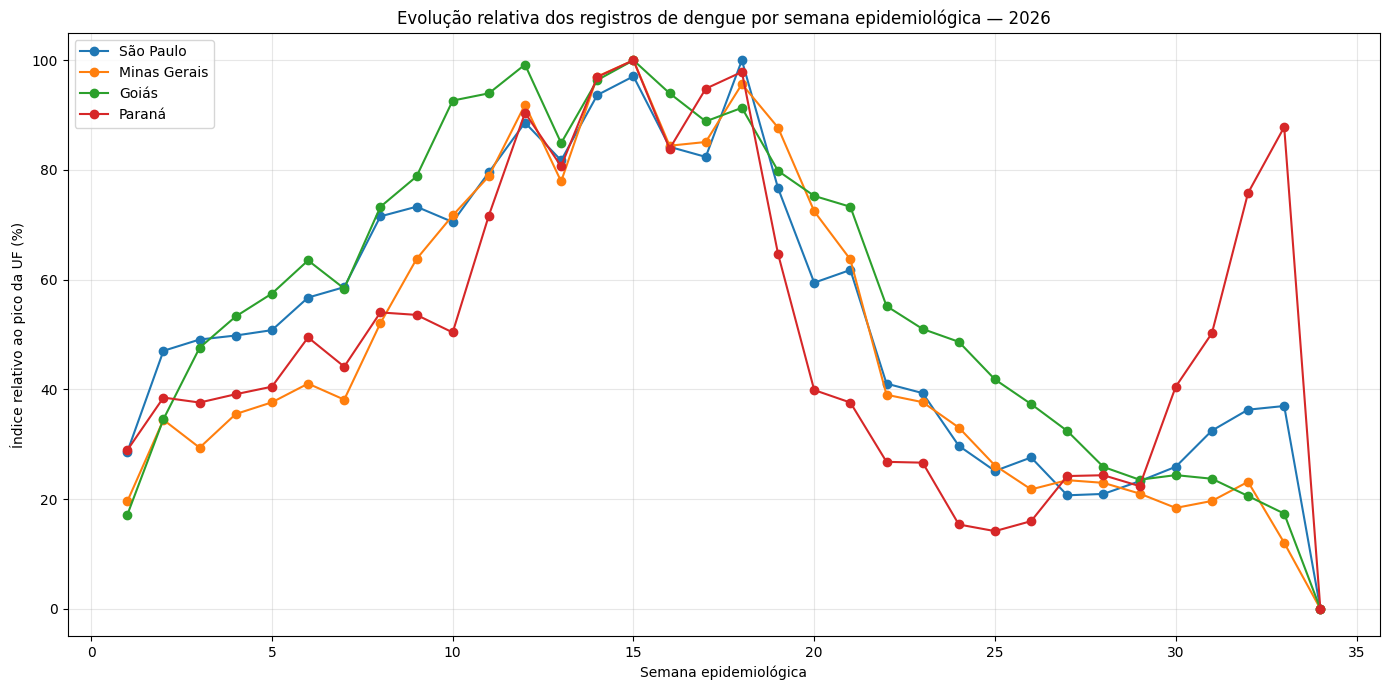

In [108]:
fig, ax = plt.subplots(
    figsize=(14, 7)
)

for uf in UFS_COMPARACAO:

    dados_uf = (
        dados_comparacao[
            dados_comparacao[
                "UF_NAME"
            ].eq(uf)
        ]
    )

    ax.plot(
        dados_uf[
            "SEMANA_EPIDEMIOLOGICA"
        ],
        dados_uf[
            "INDICE_RELATIVO_PICO"
        ],
        marker="o",
        label=uf
    )

ax.set_title(
    f"Evolução relativa dos registros de dengue "
    f"por semana epidemiológica — {ANO}"
)

ax.set_xlabel(
    "Semana epidemiológica"
)

ax.set_ylabel(
    "Índice relativo ao pico da UF (%)"
)

ax.legend()

ax.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

Esse gráfico permite perceber se, por exemplo:

- uma UF atingiu o pico mais cedo;
- outra atingiu o pico mais tarde;
- uma apresenta queda após o máximo;
- outra ainda está próxima do próprio máximo.

Sem o volume absoluto distorcer a comparação.

**Gráfico das UFs com maior aumento recente**

Aqui podemos fazer um gráfico mais diretamente relacionado ao Passo 9.

Vamos pegar até 10 UFs classificadas como Aumento:

In [109]:
# ============================================================
# MAIORES AUMENTOS PERCENTUAIS RECENTES
# ============================================================

dados_grafico_aumento = (
    ufs_maior_aumento
    .head(10)
    .sort_values(
        "VARIACAO_PERCENTUAL"
    )
)

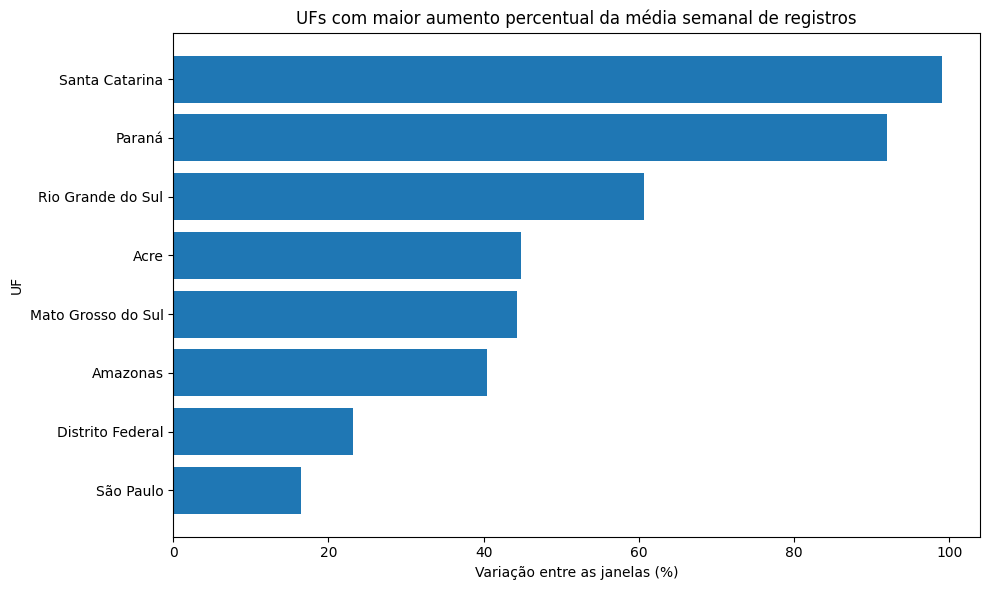

In [110]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.barh(
    dados_grafico_aumento[
        "UF_NAME"
    ],
    dados_grafico_aumento[
        "VARIACAO_PERCENTUAL"
    ]
)

ax.set_title(
    "UFs com maior aumento percentual "
    "da média semanal de registros"
)

ax.set_xlabel(
    "Variação entre as janelas (%)"
)

ax.set_ylabel(
    "UF"
)

plt.tight_layout()

plt.show()

### Interpretação

O gráfico apresenta as UFs com maior aumento percentual da média semanal
de registros entre a janela anterior e a janela recente.

A comparação é realizada entre períodos consecutivos de mesma duração,
utilizando o critério operacional definido neste notebook.

Os percentuais representam variações nas contagens médias semanais de
registros do SINAN e não devem ser interpretados diretamente como
variação da incidência ou da transmissão da dengue.

**Gráfico das maiores reduções**

In [111]:
# ============================================================
# MAIORES REDUÇÕES PERCENTUAIS RECENTES
# ============================================================

dados_grafico_reducao = (
    ufs_maior_reducao
    .head(10)
    .sort_values(
        "VARIACAO_PERCENTUAL",
        ascending=False
    )
)

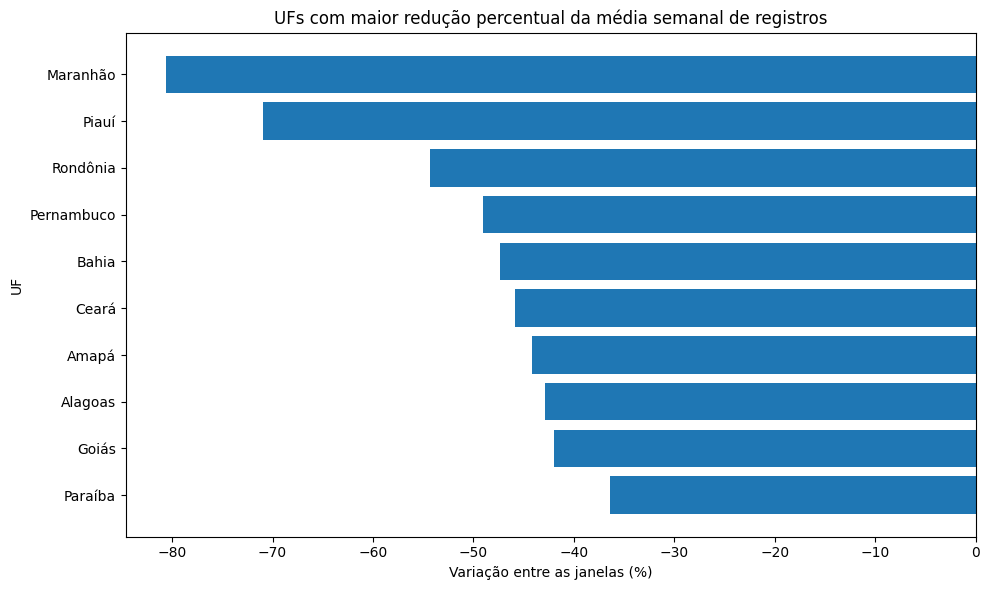

In [112]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.barh(
    dados_grafico_reducao[
        "UF_NAME"
    ],
    dados_grafico_reducao[
        "VARIACAO_PERCENTUAL"
    ]
)

ax.set_title(
    "UFs com maior redução percentual "
    "da média semanal de registros"
)

ax.set_xlabel(
    "Variação entre as janelas (%)"
)

ax.set_ylabel(
    "UF"
)

plt.tight_layout()

plt.show()

**Gráfico da distribuição dos últimos picos**

Também considero este bastante útil:

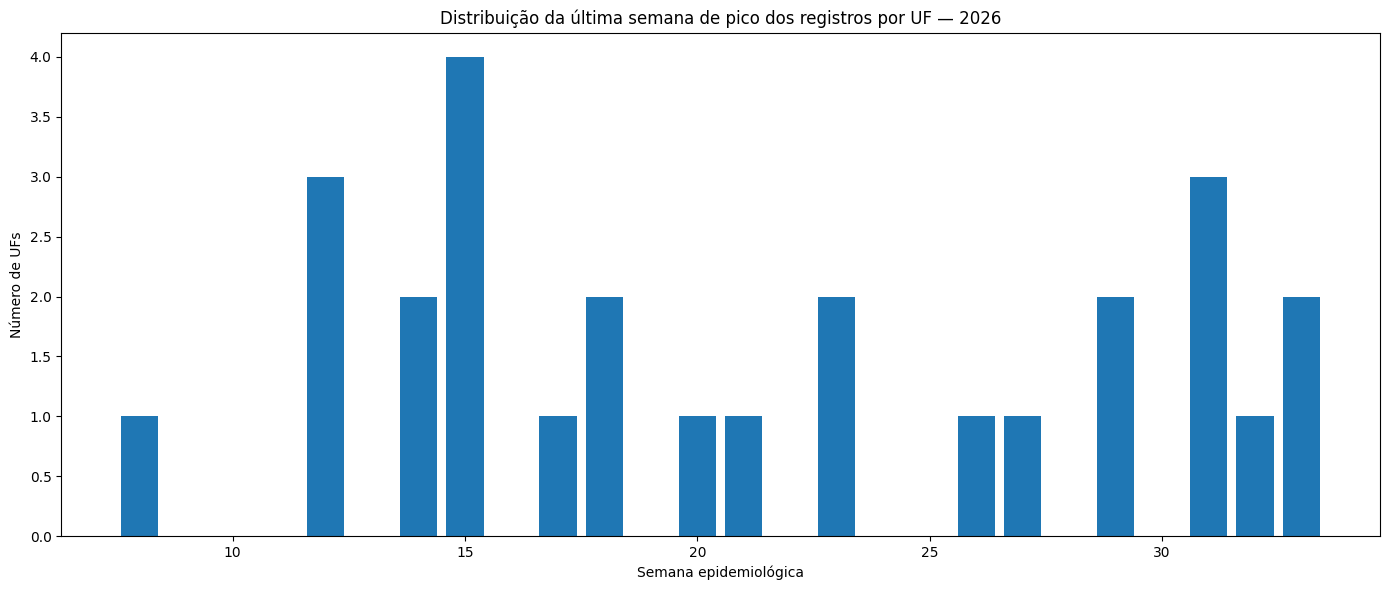

In [113]:
fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.bar(
    distribuicao_ultimo_pico_uf[
        "ULTIMA_SEMANA_PICO"
    ],
    distribuicao_ultimo_pico_uf[
        "TOTAL_UFS"
    ]
)

ax.set_title(
    f"Distribuição da última semana de pico "
    f"dos registros por UF — {ANO}"
)

ax.set_xlabel(
    "Semana epidemiológica"
)

ax.set_ylabel(
    "Número de UFs"
)

plt.tight_layout()

plt.show()

### Interpretação

O gráfico mostra a distribuição das UFs segundo a última semana
epidemiológica em que cada uma atingiu seu maior número semanal de
registros durante o período analisado.

A concentração de UFs em determinadas semanas permite comparar a posição
temporal dos máximos observados nas diferentes séries estaduais.

A semana de máximo representa o maior volume de registros observado no
período disponível e não deve ser interpretada isoladamente como o pico
epidemiológico da transmissão.

**Validações**

Primeiro, uma linha por UF na comparação:

In [114]:
# ============================================================
# VALIDAÇÃO
# ============================================================

assert (
    len(comparacao_variacao_uf)
    ==
    len(ufs_temporais)
)

assert (
    comparacao_variacao_uf[
        "SG_UF_NOT"
    ].nunique()
    ==
    len(ufs_temporais)
)

print(
    "OK — comparação temporal contém uma linha por UF."
)

OK — comparação temporal contém uma linha por UF.


A distribuição dos últimos picos deve totalizar todas as UFs:

In [115]:
assert (
    distribuicao_ultimo_pico_uf[
        "TOTAL_UFS"
    ].sum()
    ==
    len(ufs_temporais)
), (
    "A distribuição das semanas de pico "
    "não totaliza todas as UFs."
)

print(
    "OK — distribuição dos picos validada."
)

OK — distribuição dos picos validada.


E a série normalizada deve preservar o mesmo número de linhas:

In [116]:
assert (
    len(serie_temporal_uf_normalizada)
    ==
    len(serie_temporal_uf_completa)
)

print(
    "OK — série temporal normalizada validada."
)

OK — série temporal normalizada validada.


##12 - Visualizações finais

Esta seção apresenta visualizações selecionadas para sintetizar o
comportamento temporal dos registros de dengue no período analisado.

Os gráficos consideram a semana epidemiológica de notificação e devem
ser interpretados como representações do comportamento temporal dos
registros disponíveis no SINAN.

As visualizações não representam, isoladamente, medidas de incidência,
risco ou transmissão da dengue.

Evolução semanal dos registros — Brasil

Esse deve ser o principal gráfico temporal do notebook.

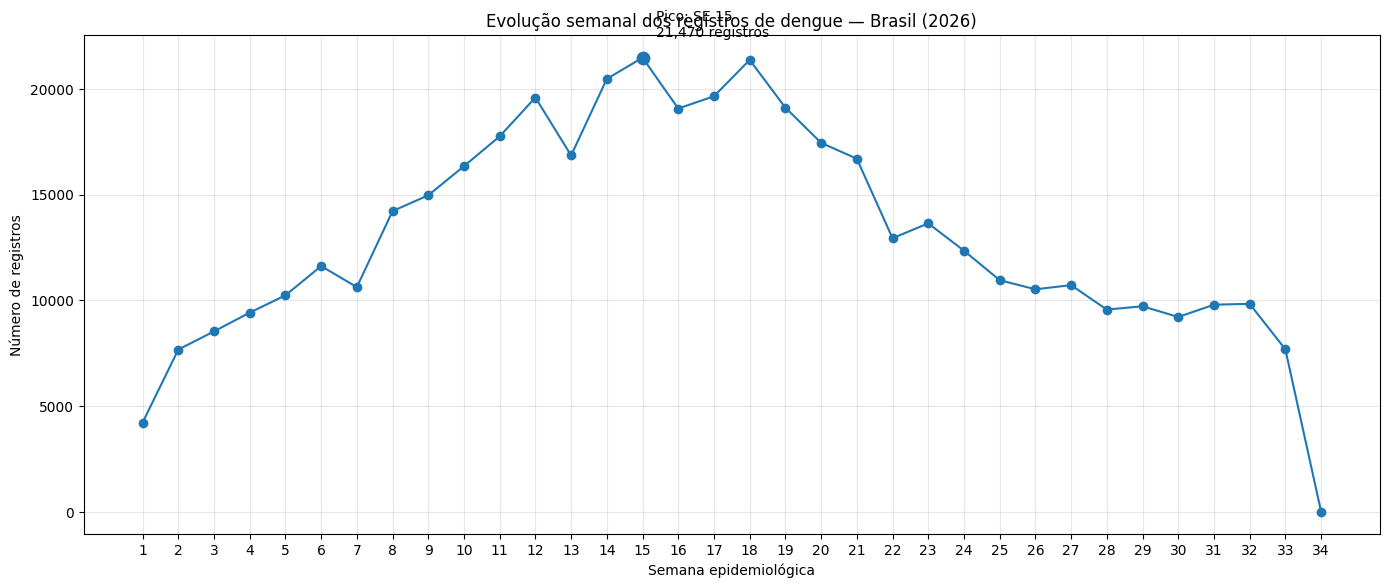

In [117]:
# ============================================================
# 12.1 — EVOLUÇÃO SEMANAL DOS REGISTROS — BRASIL
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.plot(
    serie_temporal_brasil[
        "SEMANA_EPIDEMIOLOGICA"
    ],
    serie_temporal_brasil[
        "TOTAL_REGISTROS"
    ],
    marker="o"
)

# Destacar o pico nacional
ax.scatter(
    semana_pico,
    valor_pico,
    s=80,
    zorder=3
)

ax.annotate(
    f"Pico: SE {semana_pico}\n"
    f"{valor_pico:,} registros",
    xy=(
        semana_pico,
        valor_pico
    ),
    xytext=(10, 15),
    textcoords="offset points"
)

ax.set_title(
    f"Evolução semanal dos registros de dengue — Brasil ({ANO})"
)

ax.set_xlabel(
    "Semana epidemiológica"
)

ax.set_ylabel(
    "Número de registros"
)

ax.set_xticks(
    range(
        SEMANA_INICIAL,
        SEMANA_FINAL + 1
    )
)

ax.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

### Interpretação

O gráfico apresenta a evolução do número de registros de dengue segundo
a semana epidemiológica de notificação no Brasil.

A série permite observar a distribuição temporal dos registros e
identificar a semana com o maior volume de notificações durante a janela
analisada.

O ponto destacado corresponde ao maior valor semanal observado no
período. Esse máximo representa um pico na série de registros e não deve
ser interpretado isoladamente como o pico da transmissão da dengue.

**Comparação relativa entre UFs**

Aqui utilizamos serie_temporal_uf_normalizada.

Em vez de fixar as UFs no código, podemos definir uma lista facilmente alterável:

In [118]:
# ============================================================
# 12.2 — COMPARAÇÃO RELATIVA ENTRE UFs
# ============================================================

UFS_COMPARACAO = [
    "São Paulo",
    "Minas Gerais",
    "Goiás",
    "Paraná"
]

dados_comparacao = (
    serie_temporal_uf_normalizada[
        serie_temporal_uf_normalizada[
            "UF_NAME"
        ].isin(
            UFS_COMPARACAO
        )
    ]
)

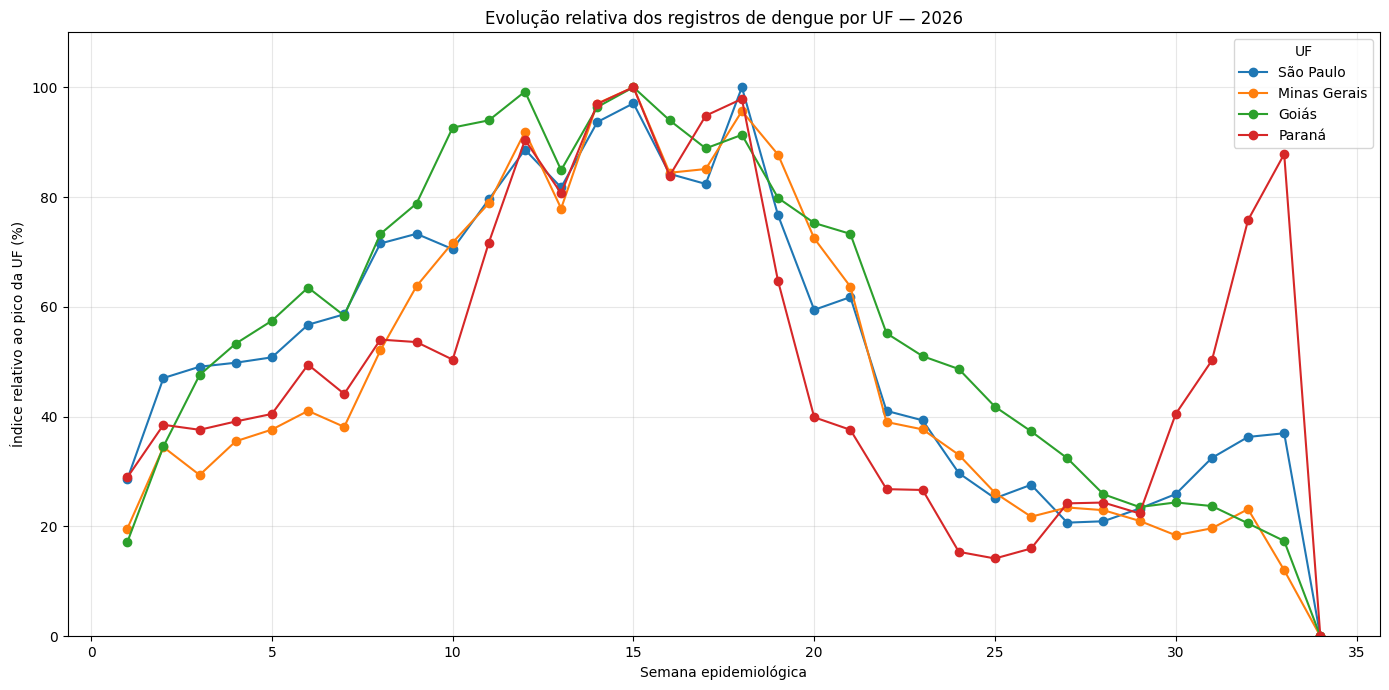

In [119]:
fig, ax = plt.subplots(
    figsize=(14, 7)
)

for uf in UFS_COMPARACAO:

    dados_uf = (
        dados_comparacao[
            dados_comparacao[
                "UF_NAME"
            ].eq(uf)
        ]
    )

    ax.plot(
        dados_uf[
            "SEMANA_EPIDEMIOLOGICA"
        ],
        dados_uf[
            "INDICE_RELATIVO_PICO"
        ],
        marker="o",
        label=uf
    )

ax.set_title(
    f"Evolução relativa dos registros de dengue "
    f"por UF — {ANO}"
)

ax.set_xlabel(
    "Semana epidemiológica"
)

ax.set_ylabel(
    "Índice relativo ao pico da UF (%)"
)

ax.set_ylim(
    0,
    110
)

ax.legend(
    title="UF"
)

ax.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

### Interpretação

As séries foram normalizadas em relação ao maior número semanal de
registros observado em cada UF. Dessa forma, o valor 100 representa o
máximo da própria UF durante o período analisado.

A normalização permite comparar o formato e a posição temporal das
curvas mesmo quando as UFs apresentam volumes absolutos de registros
muito diferentes.

O índice não representa percentual de casos, incidência ou participação
da UF no total nacional.

**Classificação da variação recente**

Agora podemos visualizar quantas UFs foram classificadas como aumento, estabilidade ou redução.

Já temos:

resumo_variacao_temporal

Vamos ordenar explicitamente:

In [120]:
# ============================================================
# 12.3 — CLASSIFICAÇÃO DA VARIAÇÃO RECENTE
# ============================================================

ordem_classificacao = [
    "Aumento",
    "Estável",
    "Redução",
    "Não classificável"
]

dados_classificacao = (
    resumo_variacao_temporal
    .set_index(
        "CLASSIFICACAO_VARIACAO"
    )
    .reindex(
        ordem_classificacao
    )
    .dropna(
        subset=["TOTAL_UFS"]
    )
    .reset_index()
)

display(
    dados_classificacao
)

,CLASSIFICACAO_VARIACAO,TOTAL_UFS,PERCENTUAL_UFS
0,Aumento,8.0,29.63
1,Estável,1.0,3.70
2,Redução,18.0,66.67


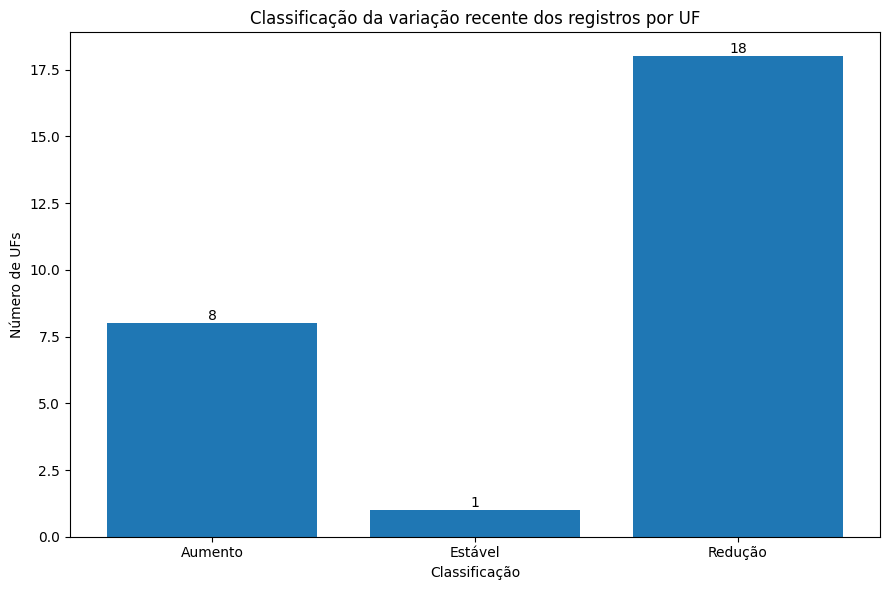

In [121]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)

barras = ax.bar(
    dados_classificacao[
        "CLASSIFICACAO_VARIACAO"
    ],
    dados_classificacao[
        "TOTAL_UFS"
    ]
)

ax.set_title(
    "Classificação da variação recente "
    "dos registros por UF"
)

ax.set_xlabel(
    "Classificação"
)

ax.set_ylabel(
    "Número de UFs"
)

# Rótulos
for barra, total in zip(
    barras,
    dados_classificacao[
        "TOTAL_UFS"
    ]
):

    ax.text(
        barra.get_x()
        + barra.get_width() / 2,

        barra.get_height(),

        f"{int(total)}",

        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()

### Interpretação

O gráfico apresenta a quantidade de UFs classificadas segundo a variação
da média semanal de registros entre a janela anterior e a janela recente.

A classificação utiliza o limiar operacional definido neste notebook:

- aumento: variação superior a +10%;
- estável: variação entre -10% e +10%;
- redução: variação inferior a -10%.

Essa classificação resume o comportamento recente das contagens de
registros e não corresponde a uma classificação epidemiológica oficial
de tendência ou transmissão.

**Maiores variações recentes**

Aqui eu faria um único gráfico, contendo aumentos e reduções, em vez de dois gráficos separados.

Primeiro selecionamos os extremos.

In [122]:
# ============================================================
# 12.4 — MAIORES VARIAÇÕES RECENTES
# ============================================================

N_UFS = 5

maiores_aumentos = (
    comparacao_variacao_uf[
        comparacao_variacao_uf[
            "VARIACAO_PERCENTUAL"
        ] > 0
    ]
    .nlargest(
        N_UFS,
        "VARIACAO_PERCENTUAL"
    )
)

maiores_reducoes = (
    comparacao_variacao_uf[
        comparacao_variacao_uf[
            "VARIACAO_PERCENTUAL"
        ] < 0
    ]
    .nsmallest(
        N_UFS,
        "VARIACAO_PERCENTUAL"
    )
)

extremos_variacao_uf = pd.concat(
    [
        maiores_reducoes,
        maiores_aumentos
    ],
    ignore_index=True
)

extremos_variacao_uf = (
    extremos_variacao_uf
    .sort_values(
        "VARIACAO_PERCENTUAL"
    )
)

display(
    extremos_variacao_uf[
        [
            "UF_NAME",
            "MEDIA_ANTERIOR",
            "MEDIA_RECENTE",
            "VARIACAO_PERCENTUAL",
            "CLASSIFICACAO_VARIACAO"
        ]
    ]
)

,UF_NAME,MEDIA_ANTERIOR,MEDIA_RECENTE,VARIACAO_PERCENTUAL,CLASSIFICACAO_VARIACAO
0,Maranhão,215.00,41.75,-80.58,Redução
1,Piauí,438.00,127.25,-70.95,Redução
2,Rondônia,40.00,18.25,-54.37,Redução
3,Pernambuco,934.25,476.00,-49.05,Redução
4,Bahia,793.25,417.50,-47.37,Redução
9,Mato Grosso do Sul,83.00,119.75,44.28,Aumento
8,Acre,45.25,65.50,44.75,Aumento
7,Rio Grande do Sul,30.50,49.00,60.66,Aumento
6,Paraná,183.00,351.25,91.94,Aumento
5,Santa Catarina,50.75,101.00,99.01,Aumento


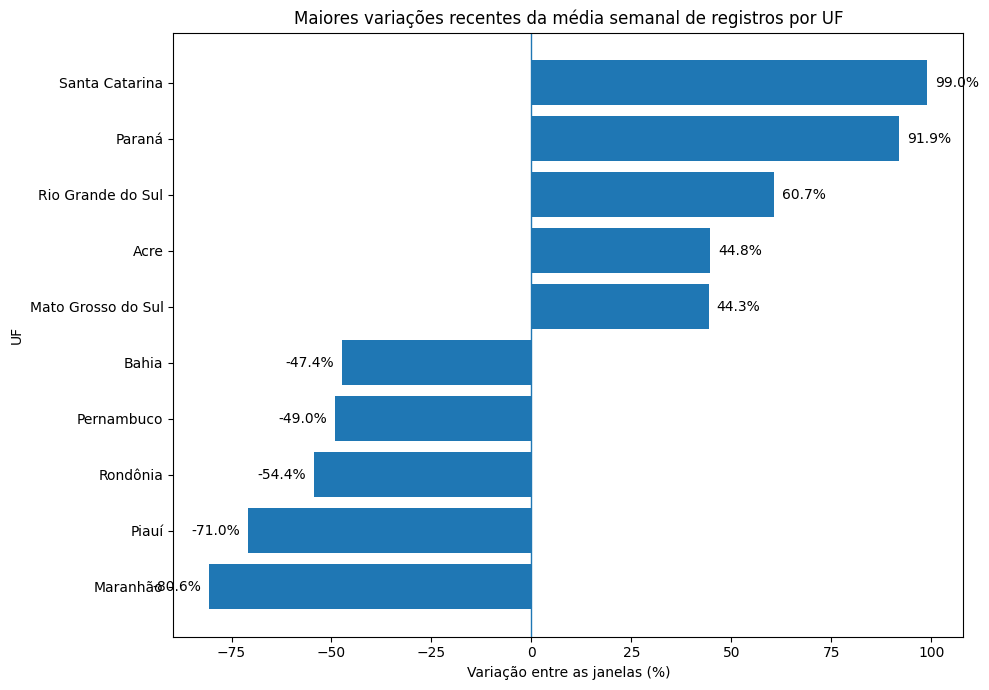

In [123]:
fig, ax = plt.subplots(
    figsize=(10, 7)
)

barras = ax.barh(
    extremos_variacao_uf[
        "UF_NAME"
    ],
    extremos_variacao_uf[
        "VARIACAO_PERCENTUAL"
    ]
)

ax.axvline(
    0,
    linewidth=1
)

ax.set_title(
    "Maiores variações recentes da média semanal "
    "de registros por UF"
)

ax.set_xlabel(
    "Variação entre as janelas (%)"
)

ax.set_ylabel(
    "UF"
)

for barra, valor in zip(
    barras,
    extremos_variacao_uf[
        "VARIACAO_PERCENTUAL"
    ]
):

    deslocamento = (
        2 if valor >= 0 else -2
    )

    alinhamento = (
        "left" if valor >= 0 else "right"
    )

    ax.text(
        valor + deslocamento,
        barra.get_y()
        + barra.get_height() / 2,
        f"{valor:.1f}%",
        va="center",
        ha=alinhamento
    )

plt.tight_layout()

plt.show()

### Interpretação

O gráfico destaca as UFs com as maiores variações percentuais positivas
e negativas entre a média semanal da janela anterior e a média da janela
recente.

Valores positivos representam aumento da média semanal de registros,
enquanto valores negativos representam redução.

A comparação é relativa ao volume anteriormente observado em cada UF.
Por esse motivo, percentuais elevados podem ocorrer também em UFs com
pequeno número absoluto de registros e devem ser analisados juntamente
com as respectivas contagens.

**Distribuição temporal do último pico das UFs**

Usamos:

distribuicao_ultimo_pico_uf

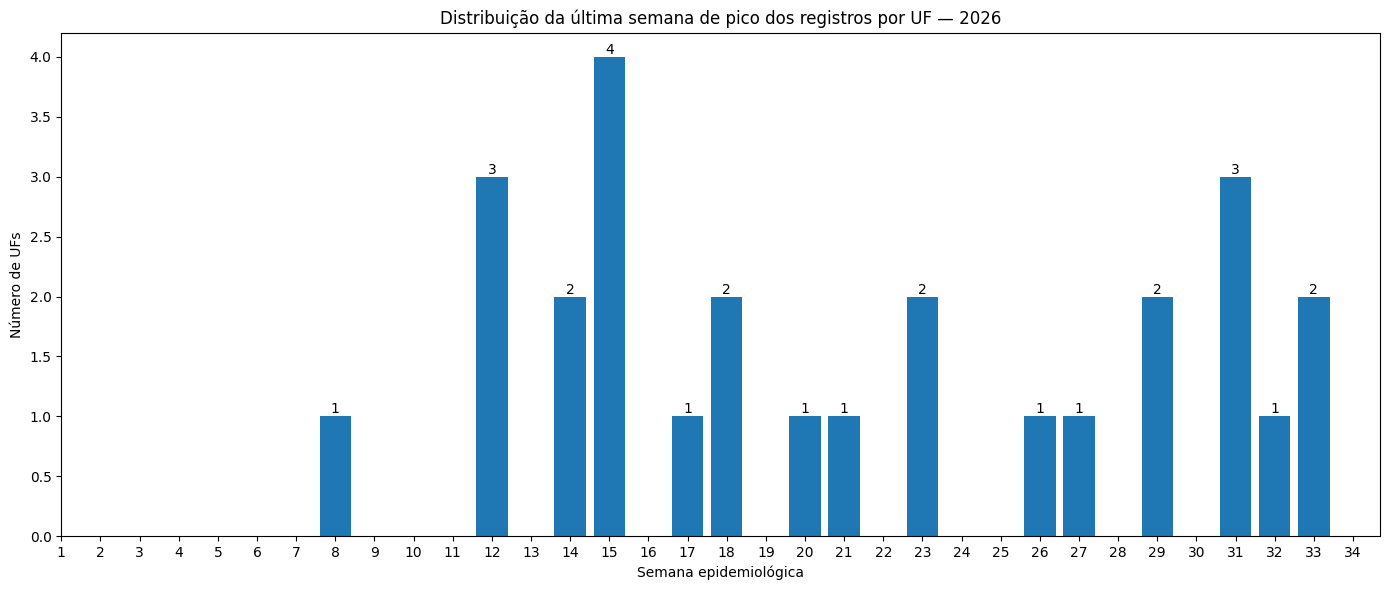

In [124]:
# ============================================================
# 12.5 — DISTRIBUIÇÃO DA ÚLTIMA SEMANA DE PICO
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 6)
)

barras = ax.bar(
    distribuicao_ultimo_pico_uf[
        "ULTIMA_SEMANA_PICO"
    ],
    distribuicao_ultimo_pico_uf[
        "TOTAL_UFS"
    ]
)

ax.set_title(
    f"Distribuição da última semana de pico "
    f"dos registros por UF — {ANO}"
)

ax.set_xlabel(
    "Semana epidemiológica"
)

ax.set_ylabel(
    "Número de UFs"
)

ax.set_xticks(
    range(
        SEMANA_INICIAL,
        SEMANA_FINAL + 1
    )
)

for barra, total in zip(
    barras,
    distribuicao_ultimo_pico_uf[
        "TOTAL_UFS"
    ]
):

    ax.text(
        barra.get_x()
        + barra.get_width() / 2,

        barra.get_height(),

        f"{int(total)}",

        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()

### Interpretação

O gráfico apresenta a distribuição das UFs segundo a última semana
epidemiológica em que foi observado o maior número semanal de registros
durante o período analisado.

A visualização permite verificar se os máximos das séries estaduais se
concentraram em períodos semelhantes ou ocorreram em diferentes momentos
da janela temporal.

Nos casos em que uma UF apresentou mais de uma semana empatada no valor
máximo, considera-se neste gráfico a última ocorrência desse máximo.

A semana de máximo representa o maior volume semanal de registros
observado na base e não deve ser interpretada isoladamente como o pico
epidemiológico da transmissão.

**Quadro-resumo das visualizações**


| Visualização          | Pergunta respondida                                         |
| --------------------- | ----------------------------------------------------------- |
| Série Brasil          | Como os registros evoluíram ao longo das semanas?           |
| Séries normalizadas   | Como o formato das curvas difere entre UFs?                 |
| Classificação recente | Quantas UFs apresentaram aumento, estabilidade ou redução?  |
| Maiores variações     | Quais UFs tiveram as maiores mudanças relativas recentes?   |
| Último pico           | Em quais semanas ocorreram os máximos das séries estaduais? |


### Observação metodológica

As visualizações apresentadas nesta seção possuem caráter descritivo e
sintetizam diferentes aspectos do comportamento temporal dos registros
de dengue disponíveis no SINAN.

As análises consideram contagens de registros segundo a semana
epidemiológica de notificação. Consequentemente, aumentos, reduções,
picos e variações identificados nas séries não devem ser interpretados
isoladamente como mudanças equivalentes na incidência ou na transmissão
da dengue.

Além da dinâmica epidemiológica, o comportamento das séries pode ser
influenciado pelo processo de notificação, atualização e consolidação
dos registros.

## 13 — Produtos finais
## 13.1 Verificar os produtos esperados

Antes de montar o dicionário, verificamos se todos os DataFrames necessários foram efetivamente criados.

In [125]:
# ============================================================
# 13 — PRODUTOS FINAIS
# ============================================================

produtos_esperados = [

    # Brasil
    "serie_temporal_brasil",
    "resumo_temporal_brasil",

    # Séries por UF
    "serie_temporal_uf_completa",
    "serie_temporal_uf_normalizada",

    # Indicadores
    "indicadores_temporais_uf",
    "distribuicao_picos_uf",

    # Variação recente
    "variacao_temporal_uf",
    "resumo_variacao_temporal",

    # Picos
    "semanas_pico_uf",
    "pico_comportamento_uf",
    "resumo_pico_recente",

    # Comparações
    "comparacao_variacao_uf",
    "comparacao_picos_uf",
    "distribuicao_ultimo_pico_uf"
]

for produto in produtos_esperados:

    if produto in globals():

        print(
            f"OK      {produto}"
        )

    else:

        print(
            f"AUSENTE {produto}"
        )

OK      serie_temporal_brasil
OK      resumo_temporal_brasil
OK      serie_temporal_uf_completa
OK      serie_temporal_uf_normalizada
OK      indicadores_temporais_uf
OK      distribuicao_picos_uf
OK      variacao_temporal_uf
OK      resumo_variacao_temporal
OK      semanas_pico_uf
OK      pico_comportamento_uf
OK      resumo_pico_recente
OK      comparacao_variacao_uf
OK      comparacao_picos_uf
OK      distribuicao_ultimo_pico_uf


## 13.2 Construir PRODUTOS_TEMPORAIS

Agora consolidamos os produtos:

In [126]:
# ============================================================
# DICIONÁRIO DE PRODUTOS TEMPORAIS
# ============================================================

PRODUTOS_TEMPORAIS = {

    # --------------------------------------------------------
    # Brasil
    # --------------------------------------------------------

    "serie_temporal_brasil":
        serie_temporal_brasil,

    "resumo_temporal_brasil":
        resumo_temporal_brasil,


    # --------------------------------------------------------
    # Séries temporais por UF
    # --------------------------------------------------------

    "serie_temporal_uf":
        serie_temporal_uf_completa,

    "serie_temporal_uf_normalizada":
        serie_temporal_uf_normalizada,


    # --------------------------------------------------------
    # Indicadores temporais
    # --------------------------------------------------------

    "indicadores_temporais_uf":
        indicadores_temporais_uf,

    "distribuicao_picos_uf":
        distribuicao_picos_uf,


    # --------------------------------------------------------
    # Variação temporal recente
    # --------------------------------------------------------

    "variacao_temporal_uf":
        variacao_temporal_uf,

    "resumo_variacao_temporal":
        resumo_variacao_temporal,


    # --------------------------------------------------------
    # Semanas de pico
    # --------------------------------------------------------

    "semanas_pico_uf":
        semanas_pico_uf,

    "pico_comportamento_uf":
        pico_comportamento_uf,

    "resumo_pico_recente":
        resumo_pico_recente,


    # --------------------------------------------------------
    # Comparações entre UFs
    # --------------------------------------------------------

    "comparacao_variacao_uf":
        comparacao_variacao_uf,

    "comparacao_picos_uf":
        comparacao_picos_uf,

    "distribuicao_ultimo_pico_uf":
        distribuicao_ultimo_pico_uf
}

Observe que no dicionário eu renomeei:

serie_temporal_uf_completa

para:

serie_temporal_uf

Isso é proposital. A versão completa é a versão analítica definitiva; portanto, não há necessidade de carregar _completa para o nome do arquivo final.

## 13.3 Por que não salvar todos os DataFrames?

Ao longo do notebook criamos vários objetos auxiliares, por exemplo:

- todas_semanas
- ufs_temporais
- grade_uf_semana
- semanas_temporais
- semanas_por_uf

- estatisticas_temporais_uf
- maximo_por_uf
- quantidade_picos_uf
- limites_pico_uf
- semanas_pico_consolidadas
- pico_recente_uf

- serie_anterior_uf
- serie_recente_uf
- janela_anterior_uf
- janela_recente_uf

- ufs_maior_aumento
- ufs_maior_reducao
- ufs_pico_recente

- dados_comparacao
- dados_classificacao
- extremos_variacao_uf

Esses objetos são úteis para processamento e visualização, mas não precisam se tornar produtos persistentes.

Isso evita transformar data_analytics em uma coleção de resultados intermediários.

## 13.4 Descrição dos produtos

Assim como fizemos no notebook de autoctonia, vamos associar uma descrição a cada produto.

In [127]:
# ============================================================
# DESCRIÇÃO DOS PRODUTOS TEMPORAIS
# ============================================================

DESCRICAO_PRODUTOS_TEMPORAIS = {

    "serie_temporal_brasil":
        "Distribuição semanal dos registros de dengue "
        "no Brasil segundo a semana epidemiológica de notificação.",

    "resumo_temporal_brasil":
        "Resumo dos principais indicadores da série temporal "
        "nacional durante a janela analisada.",

    "serie_temporal_uf":
        "Séries semanais completas dos registros de dengue "
        "segundo UF de notificação.",

    "serie_temporal_uf_normalizada":
        "Séries temporais estaduais normalizadas em relação "
        "ao maior valor semanal observado em cada UF.",

    "indicadores_temporais_uf":
        "Indicadores descritivos das séries semanais por UF, "
        "incluindo média, mediana, pico e variabilidade.",

    "distribuicao_picos_uf":
        "Distribuição das UFs segundo a semana epidemiológica "
        "em que ocorreu o máximo semanal identificado.",

    "variacao_temporal_uf":
        "Comparação da média semanal de registros entre "
        "a janela anterior e a janela recente para cada UF.",

    "resumo_variacao_temporal":
        "Distribuição das UFs segundo a classificação operacional "
        "de aumento, estabilidade ou redução recente.",

    "semanas_pico_uf":
        "Semanas epidemiológicas que atingiram o maior número "
        "semanal de registros em cada UF, preservando empates.",

    "pico_comportamento_uf":
        "Síntese por UF relacionando semanas de pico, distância "
        "do pico, janela recente e variação temporal.",

    "resumo_pico_recente":
        "Distribuição das UFs segundo a ocorrência ou não "
        "de pico dentro da janela temporal recente.",

    "comparacao_variacao_uf":
        "Comparação entre UFs segundo a variação da média "
        "semanal entre as janelas anterior e recente.",

    "comparacao_picos_uf":
        "Comparação entre UFs segundo a posição temporal "
        "dos máximos semanais observados.",

    "distribuicao_ultimo_pico_uf":
        "Distribuição das UFs segundo a última semana "
        "epidemiológica em que ocorreu o máximo semanal."
}

In [128]:
# ============================================================
# PRODUTOS TEMPORAIS FINAIS
# ============================================================

PRODUTOS_TEMPORAIS = {

    # Brasil
    "serie_temporal_brasil":
        serie_temporal_brasil,

    "resumo_temporal_brasil":
        resumo_temporal_brasil,

    # Séries por UF
    "serie_temporal_uf":
        serie_temporal_uf_completa,

    "serie_temporal_uf_normalizada":
        serie_temporal_uf_normalizada,

    # Indicadores
    "indicadores_temporais_uf":
        indicadores_temporais_uf,

    "distribuicao_picos_uf":
        distribuicao_picos_uf,

    # Variação recente
    "variacao_temporal_uf":
        variacao_temporal_uf,

    "resumo_variacao_temporal":
        resumo_variacao_temporal,

    # Picos
    "semanas_pico_uf":
        semanas_pico_uf,

    "pico_comportamento_uf":
        pico_comportamento_uf,

    "resumo_pico_recente":
        resumo_pico_recente,

    "distribuicao_ultimo_pico_uf":
        distribuicao_ultimo_pico_uf
}

## 14 — Inventário dos produtos temporais.

Como combinamos no passo anterior, vale a pena deixar o inventário um pouco mais informativo, incluindo não só nome, descrição e dimensões, mas também a categoria analítica de cada produto.

## 14 — Inventário dos produtos temporais

14.1 Definir a categoria de cada produto

Primeiro criamos um mapeamento simples:

In [129]:
# ============================================================
# 14 — INVENTÁRIO DOS PRODUTOS TEMPORAIS
# ============================================================

CATEGORIA_PRODUTOS_TEMPORAIS = {

    "serie_temporal_brasil":
        "Brasil",

    "resumo_temporal_brasil":
        "Brasil",

    "serie_temporal_uf":
        "Série por UF",

    "serie_temporal_uf_normalizada":
        "Série por UF",

    "indicadores_temporais_uf":
        "Indicadores",

    "distribuicao_picos_uf":
        "Indicadores",

    "variacao_temporal_uf":
        "Variação recente",

    "resumo_variacao_temporal":
        "Variação recente",

    "semanas_pico_uf":
        "Picos",

    "pico_comportamento_uf":
        "Picos",

    "resumo_pico_recente":
        "Picos",

    "distribuicao_ultimo_pico_uf":
        "Picos"
}

**Validar categorias**

Antes de construir o inventário, verificamos se todo produto possui categoria.

In [130]:
# ============================================================
# VALIDAÇÃO DAS CATEGORIAS
# ============================================================

produtos_sem_categoria = (
    set(
        PRODUTOS_TEMPORAIS.keys()
    )
    -
    set(
        CATEGORIA_PRODUTOS_TEMPORAIS.keys()
    )
)

categorias_sem_produto = (
    set(
        CATEGORIA_PRODUTOS_TEMPORAIS.keys()
    )
    -
    set(
        PRODUTOS_TEMPORAIS.keys()
    )
)

print(
    "Produtos sem categoria:",
    produtos_sem_categoria
)

print(
    "Categorias sem produto:",
    categorias_sem_produto
)

Produtos sem categoria: set()
Categorias sem produto: set()


In [131]:
assert not produtos_sem_categoria

assert not categorias_sem_produto

print(
    "OK — todos os produtos possuem categoria."
)

OK — todos os produtos possuem categoria.


**Construir o inventário**

Agora podemos gerar o DataFrame.

In [132]:
# ============================================================
# CONSTRUÇÃO DO INVENTÁRIO
# ============================================================

registros_inventario = []

for nome_produto, dataframe in PRODUTOS_TEMPORAIS.items():

    registros_inventario.append({

        "PRODUTO":
            nome_produto,

        "CATEGORIA":
            CATEGORIA_PRODUTOS_TEMPORAIS[
                nome_produto
            ],

        "DESCRICAO":
            DESCRICAO_PRODUTOS_TEMPORAIS[
                nome_produto
            ],

        "TOTAL_LINHAS":
            dataframe.shape[0],

        "TOTAL_COLUNAS":
            dataframe.shape[1]

    })

inventario_produtos_temporais = pd.DataFrame(
    registros_inventario
)

display(
    inventario_produtos_temporais
)

,PRODUTO,CATEGORIA,DESCRICAO,TOTAL_LINHAS,TOTAL_COLUNAS
0,serie_temporal_brasil,Brasil,Distribuição semanal dos registros de dengue n...,34,3
1,resumo_temporal_brasil,Brasil,Resumo dos principais indicadores da série tem...,1,7
2,serie_temporal_uf,Série por UF,Séries semanais completas dos registros de den...,918,4
3,serie_temporal_uf_normalizada,Série por UF,Séries temporais estaduais normalizadas em rel...,918,6
4,indicadores_temporais_uf,Indicadores,Indicadores descritivos das séries semanais po...,27,16
5,distribuicao_picos_uf,Indicadores,Distribuição das UFs segundo a semana epidemio...,15,2
6,variacao_temporal_uf,Variação recente,Comparação da média semanal de registros entre...,27,15
7,resumo_variacao_temporal,Variação recente,Distribuição das UFs segundo a classificação o...,3,3
8,semanas_pico_uf,Picos,Semanas epidemiológicas que atingiram o maior ...,27,4
9,pico_comportamento_uf,Picos,"Síntese por UF relacionando semanas de pico, d...",27,15


Acrescentar metadados gerais

Como fizemos nos outros notebooks, adicionamos:

- ano;
- fonte;
- domínio analítico.

In [133]:
# ============================================================
# METADADOS DO INVENTÁRIO
# ============================================================

inventario_produtos_temporais.insert(
    0,
    "ANO",
    ANO
)

inventario_produtos_temporais.insert(
    1,
    "FONTE",
    "SINAN"
)

inventario_produtos_temporais.insert(
    2,
    "DOMINIO_ANALITICO",
    "Análises temporais"
)

In [134]:
display(
    inventario_produtos_temporais
)

,ANO,FONTE,DOMINIO_ANALITICO,PRODUTO,CATEGORIA,DESCRICAO,TOTAL_LINHAS,TOTAL_COLUNAS
0,2026,SINAN,Análises temporais,serie_temporal_brasil,Brasil,Distribuição semanal dos registros de dengue n...,34,3
1,2026,SINAN,Análises temporais,resumo_temporal_brasil,Brasil,Resumo dos principais indicadores da série tem...,1,7
2,2026,SINAN,Análises temporais,serie_temporal_uf,Série por UF,Séries semanais completas dos registros de den...,918,4
3,2026,SINAN,Análises temporais,serie_temporal_uf_normalizada,Série por UF,Séries temporais estaduais normalizadas em rel...,918,6
4,2026,SINAN,Análises temporais,indicadores_temporais_uf,Indicadores,Indicadores descritivos das séries semanais po...,27,16
5,2026,SINAN,Análises temporais,distribuicao_picos_uf,Indicadores,Distribuição das UFs segundo a semana epidemio...,15,2
6,2026,SINAN,Análises temporais,variacao_temporal_uf,Variação recente,Comparação da média semanal de registros entre...,27,15
7,2026,SINAN,Análises temporais,resumo_variacao_temporal,Variação recente,Distribuição das UFs segundo a classificação o...,3,3
8,2026,SINAN,Análises temporais,semanas_pico_uf,Picos,Semanas epidemiológicas que atingiram o maior ...,27,4
9,2026,SINAN,Análises temporais,pico_comportamento_uf,Picos,"Síntese por UF relacionando semanas de pico, d...",27,15


In [135]:
# ============================================================
# RESUMO DO INVENTÁRIO
# ============================================================

resumo_inventario_temporal = (
    inventario_produtos_temporais
    .groupby(
        "CATEGORIA"
    )
    .size()
    .reset_index(
        name="TOTAL_PRODUTOS"
    )
    .sort_values(
        "TOTAL_PRODUTOS",
        ascending=False
    )
)

display(
    resumo_inventario_temporal
)

,CATEGORIA,TOTAL_PRODUTOS
2,Picos,4
0,Brasil,2
1,Indicadores,2
3,Série por UF,2
4,Variação recente,2


In [136]:
print(
    "Total de produtos temporais:",
    len(
        inventario_produtos_temporais
    )
)

Total de produtos temporais: 12


## 15 — Salvamento dos produtos temporais.

Aqui eu manteria o mesmo padrão dos demais notebooks: 12 produtos em Parquet e o inventário em CSV com UTF-8-SIG.

15 — Salvamento dos produtos temporais
15.1 Confirmar a pasta de saída

Como você já definiu PASTA_SAIDA no início do notebook, basta confirmar que ela existe:

In [137]:
# ============================================================
# SALVAMENTO DOS PRODUTOS EM PARQUET
# ============================================================

arquivos_salvos = []

for nome_produto, dataframe in PRODUTOS_TEMPORAIS.items():

    caminho_arquivo = (
        PASTA_SAIDA
        / f"{nome_produto}.parquet"
    )

    dataframe.to_parquet(
        caminho_arquivo,
        index=False
    )

    arquivos_salvos.append(
        caminho_arquivo
    )

    print(
        f"Salvo: {caminho_arquivo.name}"
    )

Salvo: serie_temporal_brasil.parquet
Salvo: resumo_temporal_brasil.parquet
Salvo: serie_temporal_uf.parquet
Salvo: serie_temporal_uf_normalizada.parquet
Salvo: indicadores_temporais_uf.parquet
Salvo: distribuicao_picos_uf.parquet
Salvo: variacao_temporal_uf.parquet
Salvo: resumo_variacao_temporal.parquet
Salvo: semanas_pico_uf.parquet
Salvo: pico_comportamento_uf.parquet
Salvo: resumo_pico_recente.parquet
Salvo: distribuicao_ultimo_pico_uf.parquet


In [138]:
print(
    f"\nTotal de produtos salvos: "
    f"{len(arquivos_salvos)}"
)


Total de produtos salvos: 12


Salvar o inventário em CSV

Agora salvamos:

inventario_produtos_temporais

Eu usaria utf-8-sig, porque facilita a abertura no Excel preservando acentos.

In [139]:
# ============================================================
# SALVAMENTO DO INVENTÁRIO
# ============================================================

ARQUIVO_INVENTARIO = (
    PASTA_SAIDA
    / f"inventario_produtos_temporais_{ANO}.csv"
)

inventario_produtos_temporais.to_csv(
    ARQUIVO_INVENTARIO,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"Inventário salvo em:\n"
    f"{ARQUIVO_INVENTARIO}"
)

Inventário salvo em:
/content/drive/MyDrive/Doutorado/arbovirus_rag/data_analytics/SINAN/2026/temporais/inventario_produtos_temporais_2026.csv


In [140]:
# ============================================================
# RESUMO DO SALVAMENTO
# ============================================================

print(
    "=" * 60
)

print(
    "SALVAMENTO DOS PRODUTOS TEMPORAIS"
)

print(
    "=" * 60
)

print(
    f"Ano: {ANO}"
)

print(
    "Fonte: SINAN"
)

print(
    f"Produtos Parquet: "
    f"{len(PRODUTOS_TEMPORAIS)}"
)

print(
    f"Inventário: "
    f"{ARQUIVO_INVENTARIO.name}"
)

print(
    f"Pasta: "
    f"{PASTA_SAIDA}"
)

print(
    "=" * 60
)

SALVAMENTO DOS PRODUTOS TEMPORAIS
Ano: 2026
Fonte: SINAN
Produtos Parquet: 12
Inventário: inventario_produtos_temporais_2026.csv
Pasta: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_analytics/SINAN/2026/temporais


## 15 — Salvamento dos produtos analíticos

Os produtos resultantes das análises temporais foram persistidos em
formato Parquet no diretório de produtos analíticos do SINAN.

O formato Parquet foi utilizado por preservar os tipos das variáveis,
apresentar armazenamento eficiente e facilitar a reutilização dos
resultados em etapas posteriores do pipeline.

Também foi gerado um inventário em formato CSV contendo informações
sobre os produtos produzidos, incluindo descrição, categoria, nível de
agregação, escopo temporal, configuração da janela recente e dimensões
dos respectivos DataFrames.

Os produtos salvos serão utilizados posteriormente na consolidação
analítica e na geração dos documentos semânticos.